# 1. Importamos las librerías

Corremos esta celda si no tenemos las librerías instaladas.

In [1]:
# pip install requests matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Cargamos el DataFrame

In [3]:
df_maestro = pd.read_csv('https://media.githubusercontent.com/media/clararodriguezacevedo/descriptiva-real-estate/refs/heads/main/data/raw/dataframe_maestro.tsv', sep='\t')
# df_maestro = pd.read_csv('../data/raw/dataframe_maestro.tsv', sep='\t')

Revisamos si se cargó bien.

In [4]:
df_maestro.head()

,Fecha_Scraping,Posting_ID,Sito,Operación,Precio,Expensas,Calle,Altura,Piso,Barrio,...,Descripción,Link,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
0,2026-04-12,58757240,zonaprop,alquiler,$ 750.000,$ 300.000,Mansilla,2936.0,NaN,Barrio Norte,...,Amplio departamento de dos ambientes en el exc...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,0,0,1,0
1,2026-04-12,58818211,zonaprop,alquiler,$ 1.700.000,$ 400.000,Cespedes,2300.0,NaN,Belgrano,...,"3 ambientes con balcón, y terraza con parrilla...",https://www.zonaprop.com.ar/propiedades/clasif...,1,0,0,0,1,0,0,0
2,2026-04-12,58564550,zonaprop,alquiler,USD 2.500,$ 1.150.000,Riobamba,1200.0,NaN,Recoleta,...,Departamento en alquiler de 4 ambientes con co...,https://www.zonaprop.com.ar/propiedades/clasif...,4,0,0,0,1,1,1,0
3,2026-04-12,58314210,zonaprop,alquiler,USD 1.300,NaN,Pereyra Lucena,2500.0,NaN,Palermo,...,Amoblado y Equipado. Ubicado a metros de Av. L...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,1,0,1,1
4,2026-04-12,58810878,zonaprop,alquiler,USD 3.800,NaN,Lola Mora,400.0,NaN,Puerto Madero,...,Alquiler temporario de 3 ambientes amueblado e...,https://www.zonaprop.com.ar/propiedades/clasif...,3,0,0,0,1,1,0,0


In [5]:
df_maestro.shape

(66180, 21)

Hacemos una copia para no modificar el DataFrame original.

In [6]:
df = df_maestro.copy()

# 3. Análisis Inicial

## Variables Categóricas y Numéricas

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66180 entries, 0 to 66179
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha_Scraping     66180 non-null  object 
 1   Posting_ID         66180 non-null  int64  
 2   Sito               66180 non-null  object 
 3   Operación          66180 non-null  object 
 4   Precio             66180 non-null  object 
 5   Expensas           45549 non-null  object 
 6   Calle              60722 non-null  object 
 7   Altura             60722 non-null  float64
 8   Piso               15167 non-null  object 
 9   Barrio             66180 non-null  object 
 10  Detalles           65957 non-null  object 
 11  Descripción        65868 non-null  object 
 12  Link               66180 non-null  object 
 13  Amenities          66180 non-null  int64  
 14  Losa_Central       66180 non-null  int64  
 15  Aire_Acond         66180 non-null  int64  
 16  Apto_Credito       661

Identificamos qué variables son numéricas y cuáles son categóricas, ya que cada grupo requiere un tratamiento distinto durante el análisis.

In [8]:
df.columns

Index(['Fecha_Scraping', 'Posting_ID', 'Sito', 'Operación', 'Precio',
       'Expensas', 'Calle', 'Altura', 'Piso', 'Barrio', 'Detalles',
       'Descripción', 'Link', 'Amenities', 'Losa_Central', 'Aire_Acond',
       'Apto_Credito', 'Cochera', 'Seguridad', 'Luminoso',
       'Balcon_Aterrazado'],
      dtype='object')

In [9]:
df.describe()

,Posting_ID,Altura,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
count,6.618000e+04,60722.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000
mean,3.692180e+07,2255.691726,1.272635,0.097749,0.316893,0.072983,0.288697,0.213796,0.601224,0.091674
std,2.008695e+07,1714.396910,1.714579,0.296977,0.465269,0.260110,0.453160,0.409987,0.489650,0.288568
min,1.527159e+06,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.863395e+07,950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.938779e+07,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,5.842992e+07,3100.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,5.882838e+07,54300.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Normalizamos

Normalizamos los nombres de las columnas.

In [10]:
df = df.rename(columns={"Sito": "sitio","Operación": "operacion"})

In [11]:
df.columns = (df.columns.str.lower())

Normalizamos los nombres de los barrios para facilitar los análisis posteriores.

In [12]:
mapeo = {
    "Palermo Nuevo": "Palermo",
    "Palermo Viejo": "Palermo",
    "Palermo Hollywood": "Palermo",
    "Palermo Soho": "Palermo",
    "Palermo Chico": "Palermo",
    "Las Cañitas": "Palermo",
    "Botanico": "Palermo",
    "Botánico": "Palermo",

    "Belgrano R": "Belgrano",
    "Belgrano C": "Belgrano",
    "Belgrano Chico": "Belgrano",
    "Belgrano Barrancas": "Belgrano",
    "Barrio Chino": "Belgrano",

    "Almagro Norte": "Almagro",
    "Almagro Sur": "Almagro",
    "Abasto": "Almagro",

    "Caballito Norte": "Caballito",
    "Caballito Sur": "Caballito",
    "Parque Rivadavia": "Caballito",
    "Primera Junta": "Caballito",
    "Cid Campeador": "Caballito",

    "Flores Norte": "Flores",
    "Flores Sur": "Flores",

    "Floresta Norte": "Floresta",
    "Floresta Sur": "Floresta",

    "Centro": "San Nicolas",
    "Microcentro": "San Nicolas",
    "Centro / Microcentro": "San Nicolas",
    "San Nicolás": "San Nicolas",
    "Tribunales": "San Nicolas",
    "Congreso": "San Nicolas",

    "Núñez": "Nuñez",
    "Lomas De Núñez": "Nuñez",
    "Lomas De Nuñez": "Nuñez",
    "River": "Nuñez",

    "Constitución": "Constitucion",
    "Concepción": "San Cristobal",
    "Once": "Balvanera",
    "Pompeya": "Nueva Pompeya",

    "Barrio Norte": "Recoleta",
    "Plaza San Martín": "Retiro",
    "Catalinas": "Retiro",
    "Puerto Retiro": "Retiro",

    "Parque Centenario": "Caballito",
    "Parque Las Heras": "Palermo",

    "Urquiza R": "Villa Urquiza",

    "Villa Pueyrredón": "Villa Pueyrredon",
    "Villa General Mitre": 'Villa Gral. Mitre',
    "La Paternal": "La Paternal",
    "Paternal": "La Paternal",
    "Los Perales": "Mataderos",
    "Agronomía": "Agronomia",

    "Boca": "La Boca",

    "Barrio Norte": "Recoleta",
    "Barrio Parque Saavedra": "Saavedra",
    "Barrio Parque General Belgrano": "Belgrano",
    "Barrio San Pedro": "Saavedra",
    "Barrio Justo Suarez": "Villa Urquiza",
    "Barrio Naón": "Agronomia",
    "Naón": "Agronomia",
    "Barrio Parque": "Palermo",
    "Distrito Quartier": "Puerto Madero",

    "Otro": None, 
}

df["barrio_norm"] = df["barrio"].str.strip().str.title()
df["barrio_oficial"] = df["barrio_norm"].replace(mapeo)

## Revisamos duplicados

Identificamos las filas duplicadas y eliminamos los registros idénticos.

In [13]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 3243


In [14]:
df = df.drop_duplicates(keep = 'first').reset_index(drop=True)

In [15]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


# 4. Tratamos las columnas precio y expensas

### Precio

Vemos cuáles son los indicadores de moneda que acompañan al precio.

In [16]:
df_prueba = df.copy()
# Aseguramos que sea string y quitamos espacios extremos
df_prueba['columna_precio'] = df_prueba['precio'].astype(str).str.strip()

# Para el precio quitamos todo lo que no sea número, coma o punto
df_prueba['precio_num'] = df_prueba['columna_precio'].str.replace(r'[^0-9,\.]', '', regex=True)

# Para la moneda quitamos números, puntos, comas y espacios

df_prueba['simbolo_detectado'] = df_prueba['columna_precio'].str.replace(r'[0-9,\.\s]', '', regex=True)

# Verificamos qué quedó
print(df_prueba['simbolo_detectado'].unique())

['$' 'USD' 'Consultar']


Los únicos valores detectados son '$', 'USD' y 'Consultar'. Consideramos que los precios marcados como 'USD' están en dólares y los demás en pesos. Los que dicen 'Consultar' quedan como NaN para tratarlos más adelante.

In [17]:
import re

# Detectamos la moneda a partir del texto del precio, incluyendo variaciones comunes
patron_usd = r'usd|u\$s|u\$d|us\$|dolar(es)?|dollar(s)?'

df['moneda'] = df['precio'].apply(
    lambda x: 'usd' if re.search(patron_usd, str(x).lower()) else 'ars'
)

print("Distribución de monedas detectadas:")
print(df['moneda'].value_counts())

Distribución de monedas detectadas:
moneda
usd    46128
ars    16809
Name: count, dtype: int64


Limpiamos el texto del precio eliminando todos los indicadores de moneda y símbolos

In [18]:
df['precio'] = (
    df['precio']
    .astype(str)
    .str.lower()
    .str.replace(r'u\$s|u\$d|us\$', '', regex=True)
    .str.replace('usd', '', regex=False)
    .str.replace('ars', '', regex=False)
    .str.replace('dolares', '', regex=False)
    .str.replace('dolar', '', regex=False)
    .str.replace('dollars', '', regex=False)
    .str.replace('dollar', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)
df['precio'] = df['precio'].apply(lambda x: float(x) if x != 'consultar' and x != '' else np.nan)

### Expensas

Vemos cuáles son los indicadores de moneda que acompañan a las expensas.

In [19]:
# 1. Aseguramos que la columna de expensas sea string
df_prueba['expensas_raw'] = df_prueba['expensas'].astype(str).str.strip().str.lower()

# 2. Extraemos solo los números
df_prueba['expensas_num_sucio'] = df_prueba['expensas_raw'].str.replace(r'[^0-9,\.]', '', regex=True)

# 3. Detectamos si había texto útil 
df_prueba['expensas_texto'] = df_prueba['expensas_raw'].str.replace(r'[0-9,\.\s]', '', regex=True)

print("\nValores de texto encontrados en expensas:")
print(df_prueba['expensas_texto'].unique())


Valores de texto encontrados en expensas:
['$' 'nan']


Vemos que las expensas siempre están expresadas en pesos, por lo que podemos extraerlas directamente.

In [20]:
df['expensas'] = (df['expensas'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['expensas'] = df["expensas"].apply(lambda x: float(x) if x != '' else np.nan)

### Analizamos

In [21]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14458  8.282753e+05  700000.0  9.965850e+05   
       alquiler_temporal    810  7.122810e+05  750000.0  3.849273e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6879  5.346962e+03    1200.0  5.369935e+04   
       alquiler_temporal   6065  5.744404e+03     850.0  2.247339e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler               1.0  111111111.0  
       alquiler_temporal      1.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      5.0   12322222.0  
       venta                  1.0   12000000.0

### Observación sobre valores mínimos y máximos ficticios

Prácticamente todos los segmentos (moneda × operación) presentan un mínimo de 1 o valores extremadamente bajos. Estos no son precios reales, sino publicaciones donde el vendedor no quiso revelar el precio y usó un valor simbólico como marcador de posición (por ejemplo, "1 peso").

Del mismo modo, los valores máximos extremos como 111.111.111 ARS o 12.322.222 USD pueden ser artificiales. Una práctica habitual en portales inmobiliarios es ingresar valores como "111111111" o "999999999" para indicar que el precio está a consultar, en lugar de dejar el campo vacío.

Estos valores ficticios distorsionan cualquier análisis estadístico (medias, desvíos, visualizaciones), por lo que los removemos mediante un proceso de detección de outliers.

### Visualización de precios por segmento

Graficar todos los segmentos en un mismo eje sería engañoso porque los precios en ARS y en USD difieren en órdenes de magnitud, y los alquileres y las ventas tampoco son comparables entre sí. Por eso usamos subplots independientes con escala libre en cada eje, de modo que cada combinación (moneda × operación) sea legible por separado.

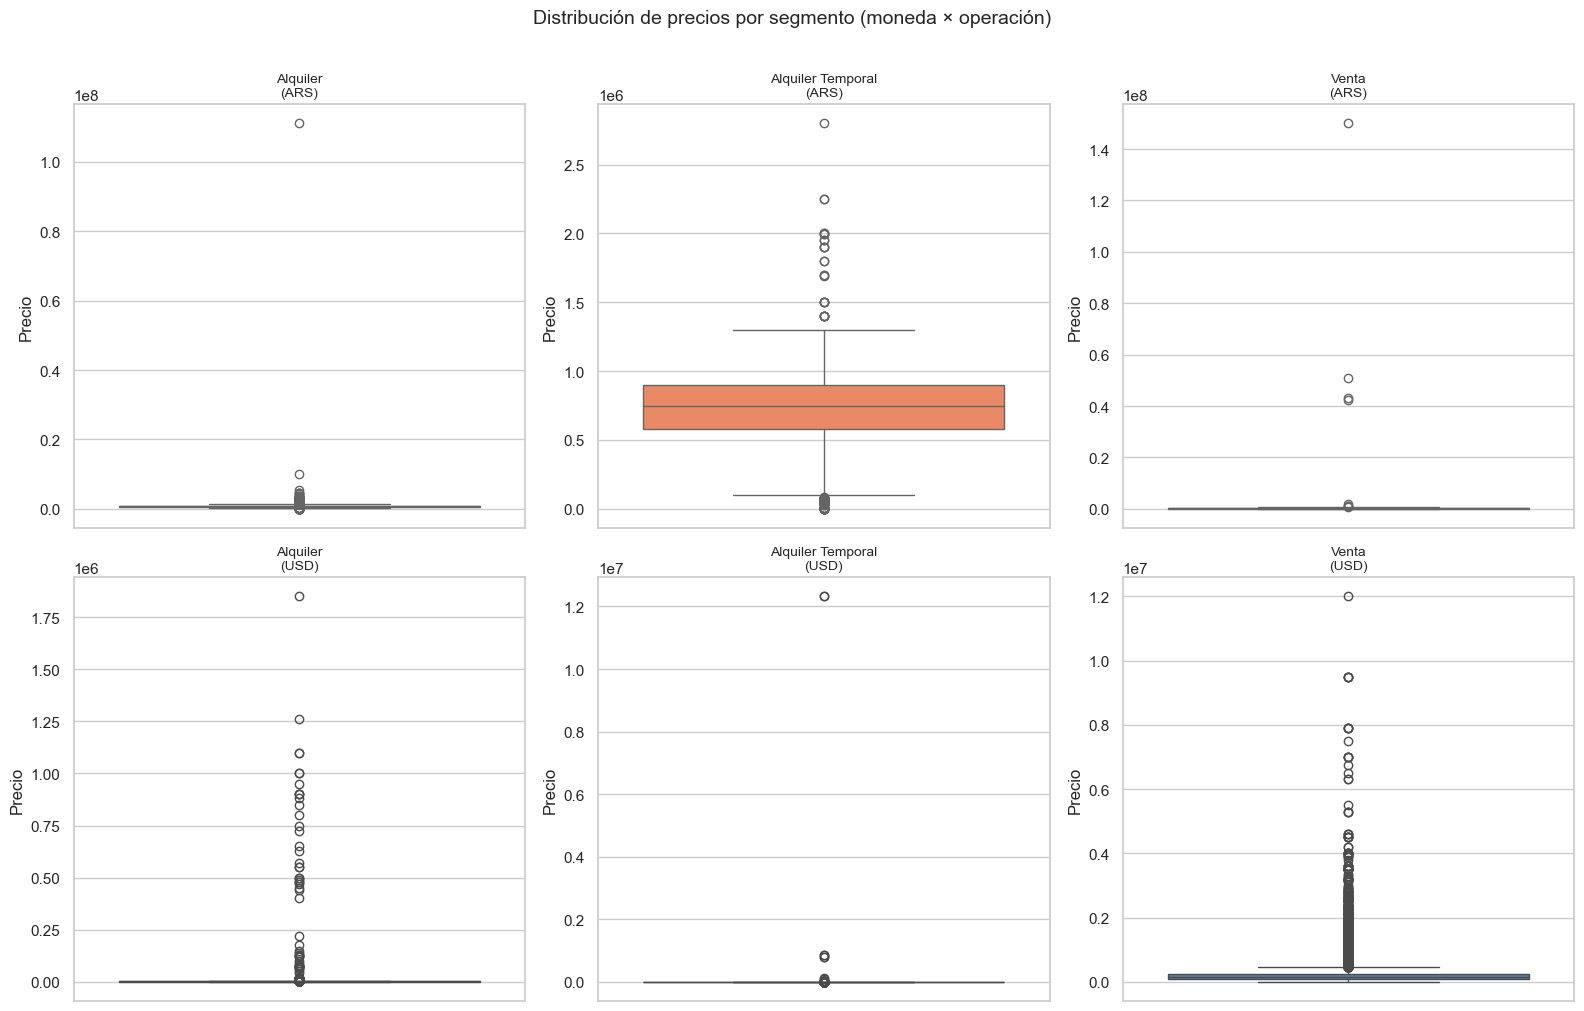

In [22]:
df_plot = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# Definimos los segmentos a graficar
monedas = ['ars', 'usd']
operaciones = ['alquiler', 'alquiler_temporal', 'venta']

fig, axes = plt.subplots(
    nrows=len(monedas),
    ncols=len(operaciones),
    figsize=(16, 10),
    sharex=False,
    sharey=False
)

for i, moneda in enumerate(monedas):
    for j, operacion in enumerate(operaciones):
        ax = axes[i][j]
        subset = df_plot[(df_plot['moneda'] == moneda) & (df_plot['operacion'] == operacion)]['precio'].dropna()

        if len(subset) > 0:
            sns.boxplot(y=subset, ax=ax, color='steelblue' if moneda == 'usd' else 'coral')
            ax.set_title(f"{operacion.replace('_', ' ').title()}\n({moneda.upper()})", fontsize=10)
        else:
            ax.set_visible(False)

        ax.set_xlabel("")
        ax.set_ylabel("Precio")

fig.suptitle("Distribución de precios por segmento (moneda × operación)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Podemos ver una clara presencia de outliers, que no nos permiten interpretar la información del boxplot. Pero sí podemos determinar que claramente necesitamos un tratar estos outliers. 

Ahora bien, para poder entender estas distribuciones, vamos a realizar un histograma, con un rango reducido:

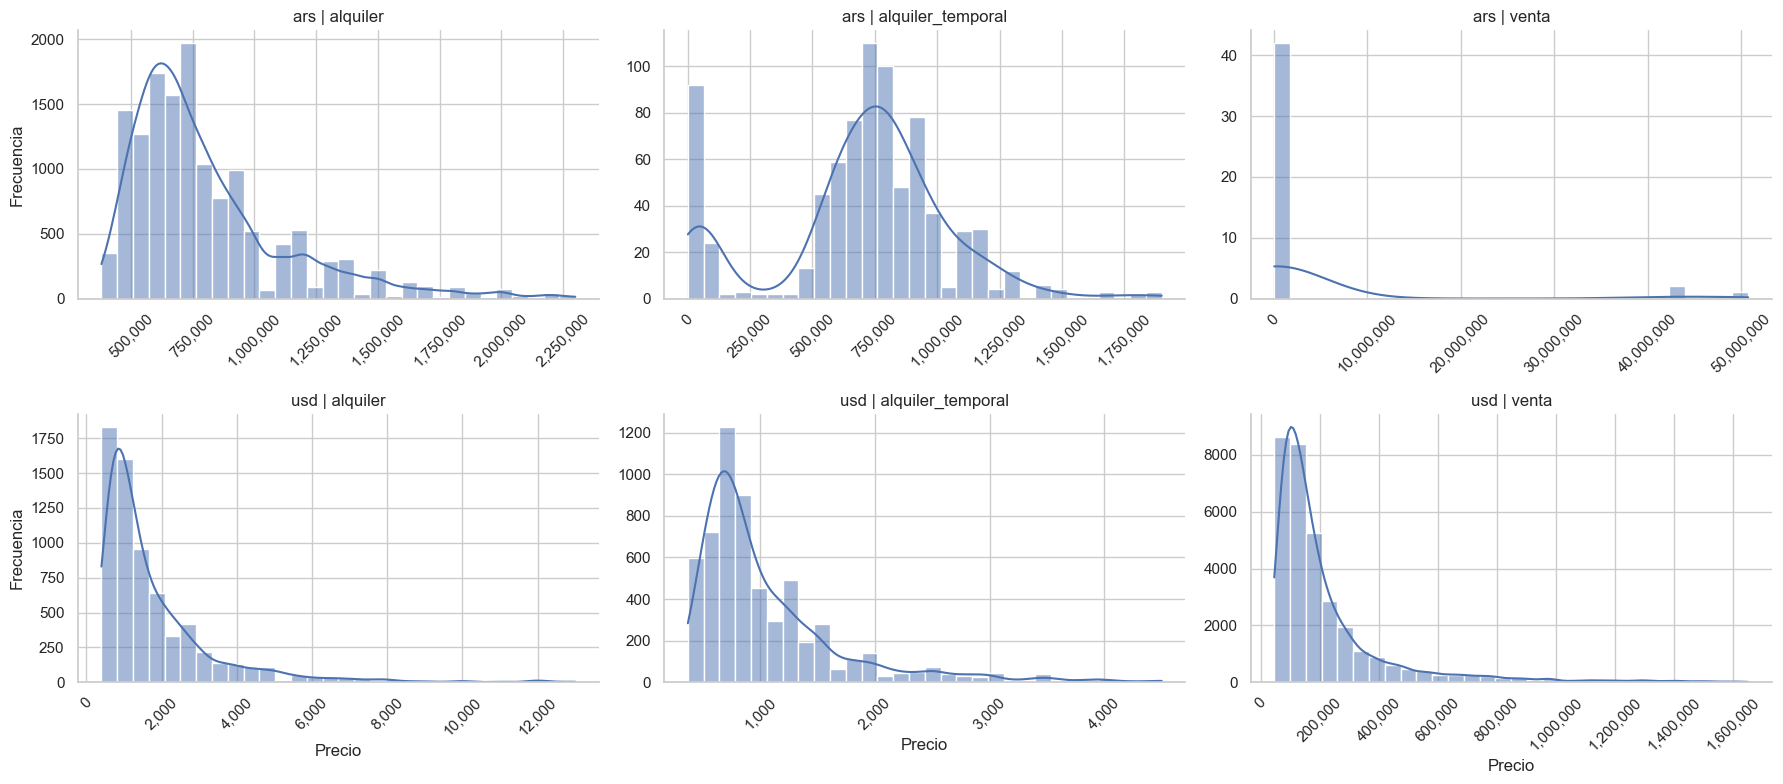

In [23]:
import matplotlib.ticker as ticker

df_precio = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# Recortamos al rango P1-P99 por segmento para la visualización.
# Los outliers extremos distorsionan el eje x y comprimen la distribución
# real en una franja muy pequeña, haciendo ilegible el gráfico.

pieces = []
for _, grupo in df_precio.groupby(['moneda', 'operacion']):
    p1  = grupo['precio'].quantile(0.01)
    p99 = grupo['precio'].quantile(0.99)
    pieces.append(grupo[(grupo['precio'] >= p1) & (grupo['precio'] <= p99)])
df_precio_clip = pd.concat(pieces).reset_index(drop=True)

g = sns.FacetGrid(df_precio_clip, row="moneda", col="operacion",
                  sharex=False, sharey=False, height=4, aspect=1.5)

g.map_dataframe(sns.histplot, x="precio", bins=30, kde=True)

for ax in g.axes.flat:
    ax.ticklabel_format(style='plain', axis='x')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.tick_params(axis='x', rotation=45)

g.set_axis_labels("Precio", "Frecuencia")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

Entonces, para mejorar la legibilidad, recortamos los precios al rango entre el percentil 1 y el percentil 99 dentro de cada segmento (moneda y tipo de operación) para esta visualización.

Podemos ver, que en casi todos los casos, los precios tienden a concentrarse a la izquierda, por lo que podemos identificar una asimetria positiva. Por la naturaleza del sistema inmobiliario, es normal que igualmente existan departamentos con valores mas altos, por ser departamentos mas lujosos, o en zonas mas premium. Esto lo tendremos en cuenta para realizar nuestro analisis.

# 5. Feature Engineering - Parseo de texto

Extraemos variables estructuradas a partir de las columnas de texto libre 'detalles' y 'descripción' mediante expresiones regulares. Luego calculamos los KPIs definidos en la entrega anterior.

In [24]:
detalles = df['detalles'].unique()
print(detalles)

['60 m² tot. 2 amb. 1 dorm. 1 baño'
 '114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.'
 '121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.' ...
 '111 m² cubie. 2 dorm. 2 baños' '90 m² cubie. 3 dorm. 27 años'
 '99 m² cubie. 2 dorm. 95 años']


Los detalles pueden incluir distintos datos, pero extraemos únicamente m², ambientes, dormitorios, baños y antigüedad, que son las variables numéricas que necesitamos.

Las demás las obtenemos de descripción, como variables binarias o categóricas (si la descripción menciona cada uno de los valores).

## Funciones

In [25]:
import pandas as pd
import re

def parse_detalles(s):
    """Parsea la columna 'detalles' de ZonaProp/ArgEnProp en columnas individuales."""
    if pd.isna(s):
        return {}
    result = {}

    # Superficie total (ej: "60 m² tot." o "60 m² cubie.")
    m_tot = re.search(r'([\d,\.]+)\s*m²\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²\s*cubie\.?', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # Ambientes (ej: "3 amb." o "3 ambientes")
    amb = re.search(r'(\d+)\s*amb\.', s)
    ambientes = re.search(r'(\d+)\s*ambientes', s)
    if amb:
        result['ambientes'] = int(amb.group(1))
    elif ambientes:
        result['ambientes'] = int(ambientes.group(1))

    # Dormitorios (ej: "2 dorm.")
    dorm = re.search(r'(\d+)\s*dorm\.', s)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # Baños (ej: "1 baño" o "2 baños")
    ban = re.search(r'(\d+)\s*baños?', s)
    if ban:
        result['baños'] = int(ban.group(1))
        
    # Antigüedad: 0 si "A estrenar", número si "X años" o año de construcción
    match_antiguedad = re.search(r'(\d+)\s*(?:años|año)', s, re.IGNORECASE)
    
    a_estrenar = re.search(r'A\s*[Ee]strenar', s)

    if a_estrenar:
        result['antiguedad_años'] = 0
    elif match_antiguedad:
        valor = int(match_antiguedad.group(1))
        if valor >= 1800:
            # Si puso 1980, calculamos la edad al 2026
            antiguedad = 2026 - valor
            result['antiguedad_años'] = max(0, antiguedad)
        elif valor >= 150:
            # probablemente sea un error, ponemos nan y lo tratamos despues
            result['antiguedad_años'] = np.nan
        else:
            # Si puso 27, son 27 años
            result['antiguedad_años'] = valor
    else:
        # Si no encuentra ninguna mención a años, lo dejamos como NaN
        result['antiguedad_años'] = np.nan

    return result

In [26]:
def parse_descripcion(s):
    if pd.isna(s):
        return {}

    s_low = s.lower()
    result = {}

    # --- Orientación ---
    if re.search(r'contra\s*frente|contrafrente', s_low):
        result['orientacion'] = 'Contra Frente'
    elif re.search(r'\bfrente\b', s_low):
        result['orientacion'] = 'Frente'
    elif re.search(r'\blateral\b', s_low):
        result['orientacion'] = 'Lateral'

    # --- Vista ---
    if re.search(r'vista\s*al?\s*r[íi]o', s_low):
        result['vista_rio'] = True
    if re.search(r'vista\s*al?\s*park|vista\s*verde|vista\s*jard[íi]n', s_low):
        result['vista_verde'] = True

    # --- Balcón ---
    if re.search(r'balc[oó]n', s_low):
        result['balcon'] = True

    # --- Terraza ---
    if re.search(r'terraza', s_low):
        result['terraza'] = True

    # --- Pileta ---
    if re.search(r'pileta|piscina', s_low):
        result['pileta'] = True

    # --- Parrilla ---
    if re.search(r'parrill[ao]', s_low):
        result['parrilla'] = True

    # --- SUM ---
    if re.search(r'\bsum\b|sal[oó]n\s*de\s*usos\s*m[uú]ltiples', s_low):
        result['sum'] = True

    # --- Laundry / Lavadero ---
    if re.search(r'laundry|lavadero', s_low):
        result['lavadero'] = True

    # --- Gimnasio ---
    if re.search(r'gimnasio|gym\b', s_low):
        result['gimnasio'] = True

    # --- Baulera ---
    if re.search(r'baulera', s_low):
        result['baulera'] = True

    # --- Calefacción ---
    if re.search(r'piso\s*radiante', s_low):
        result['calefaccion'] = 'Piso radiante'
    elif re.search(r'radiadores?', s_low):
        result['calefaccion'] = 'Radiadores'
    elif re.search(r'calefacci[oó]n\s*central', s_low):
        result['calefaccion'] = 'Central'
    elif re.search(r'calefacci[oó]n', s_low):
        result['calefaccion'] = 'Sí'

    # --- Agua caliente central ---
    if re.search(r'agua\s*caliente\s*central', s_low):
        result['agua_caliente_central'] = True

    # --- Ascensor ---
    if re.search(r'sin\s*ascensor|no\s*tiene\s*ascensor', s_low):
        result['ascensor'] = False
    elif re.search(r'ascensor', s_low):
        result['ascensor'] = True

    # --- Portero ---
    if re.search(r'portero\s*(?:el[eé]ctrico|visor|virtual)', s_low):
        result['portero'] = True

    # --- Apto profesional ---
    if re.search(r'no\s*apto\s*prof', s_low):
        result['apto_profesional'] = False
    elif re.search(r'apto\s*prof|apto\s*para\s*prof', s_low):
        result['apto_profesional'] = True

    # --- Mascotas ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:mascotas?|animales?)|no\s*mascotas?', s_low):
        result['permite_mascotas'] = 0
    elif re.search(r'acept[ao]\s*mascotas?|permite?\s*mascotas?|mascotas?\s*(?:ok|permitidas?)|apto\s*mascota', s_low):
        result['permite_mascotas'] = 1

    # --- Garantías ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = False
    elif re.search(r'(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = True
    if re.search(r'finaer', s_low):
        result['acepta_finaer'] = True

    # --- Financiación ---
    if re.search(r'financiaci[oó]n|financia\b', s_low):
        result['ofrece_financiacion'] = True

    # --- Accesibilidad ---
    if re.search(r'movilidad\s*reducida|accesible\s*para\s*personas', s_low):
        result['accesible_movilidad_reducida'] = True

    # --- Dependencia de servicio ---
    if re.search(r'dependencia\s*(?:de\s*)?servicio', s_low):
        result['dependencia_servicio'] = True

    # --- Cocina tipo ---
    if re.search(r'cocina\s*american[ao]|cocina\s*integrada|cocina\s*abierta', s_low):
        result['cocina_tipo'] = 'Americana/Integrada'
    elif re.search(r'cocina\s*independiente|cocina\s*separada', s_low):
        result['cocina_tipo'] = 'Independiente'

    # --- Expensas (responsabilidad de pago) ---
    # Caso especial: el precio publicado ya incluye las expensas en el monto
    if re.search(r'expensas?\s*incluidas?|incluye\s*expensas?', s_low):
        result['tiene_expensas'] = 0
        result['expensas_incluidas_en_precio'] = True
    elif re.search(r'sin\s*expensas?|expensas?\s*a\s*cargo\s*del\s*(propietario|due[\xf1n]o)', s_low):
        result['tiene_expensas'] = 0
    # Sin mención explícita: el default por operación se aplica más adelante

    return result


## Implementamos las funciones

In [27]:
df_det = pd.DataFrame(df['detalles'].apply(parse_detalles).tolist())

In [28]:
df_desc = pd.DataFrame(df['descripción'].apply(parse_descripcion).tolist())

In [29]:
# Detalles tiene prioridad sobre descripción por ser más confiable
combined = df_det.combine_first(df_desc)

In [30]:
bool_cols = [
    'balcon', 'terraza', 'pileta', 'parrilla', 'sum', 'lavadero', 'gimnasio',
    'baulera', 'aire_acondicionado', 'agua_caliente_central', 'ascensor',
    'portero', 'seguridad_24hs', 'apto_profesional', 'permite_mascotas',
    'acepta_caucion', 'acepta_finaer', 'ofrece_financiacion',
    'accesible_movilidad_reducida', 'dependencia_servicio',
    'vista_rio', 'vista_verde', 'monoambiente',
    'expensas_incluidas_en_precio',
]

for col in bool_cols:
    if col in combined.columns:
        combined[col] = combined[col].map({True: 1, False: 0}).fillna(0).astype(int)


In [31]:
combined.head(10)

,accesible_movilidad_reducida,acepta_caucion,acepta_finaer,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,...,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,tiene_expensas,vista_rio,vista_verde
0,0,0,0,0,2.0,NaN,0,0,1,0,...,NaN,0,0,0,0,0,1,NaN,0,0
1,0,1,0,0,3.0,NaN,0,0,1,0,...,Contra Frente,1,0,0,0,0,1,NaN,0,0
2,0,0,0,0,4.0,NaN,0,0,1,0,...,NaN,1,0,1,0,0,0,NaN,0,0
3,0,0,0,0,2.0,NaN,1,0,1,0,...,Frente,0,0,0,0,0,1,NaN,0,0
4,0,0,0,0,3.0,NaN,0,0,0,0,...,NaN,0,0,1,0,0,0,NaN,0,0
5,0,0,0,1,1.0,NaN,0,0,0,0,...,NaN,1,0,0,0,0,0,NaN,0,0
6,0,0,0,0,2.0,NaN,0,0,0,0,...,NaN,0,0,0,0,0,0,NaN,0,0
7,0,0,0,0,4.0,NaN,0,0,0,0,...,Frente,0,0,0,0,0,0,NaN,0,0
8,0,0,0,0,2.0,NaN,0,0,1,0,...,Frente,1,0,1,0,0,0,NaN,0,0
9,0,0,0,1,1.0,NaN,1,0,1,0,...,Frente,0,0,0,0,0,0,NaN,0,0


Agregamos las nuevas variables al DataFrame.

In [32]:
df_final = pd.concat([df, combined], axis=1)
df_final.head()

,fecha_scraping,posting_id,sitio,operacion,precio,expensas,calle,altura,piso,barrio,...,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,tiene_expensas,vista_rio,vista_verde
0,2026-04-12,58757240,zonaprop,alquiler,750000.0,300000.0,Mansilla,2936.0,NaN,Barrio Norte,...,NaN,0,0,0,0,0,1,NaN,0,0
1,2026-04-12,58818211,zonaprop,alquiler,1700000.0,400000.0,Cespedes,2300.0,NaN,Belgrano,...,Contra Frente,1,0,0,0,0,1,NaN,0,0
2,2026-04-12,58564550,zonaprop,alquiler,2500.0,1150000.0,Riobamba,1200.0,NaN,Recoleta,...,NaN,1,0,1,0,0,0,NaN,0,0
3,2026-04-12,58314210,zonaprop,alquiler,1300.0,NaN,Pereyra Lucena,2500.0,NaN,Palermo,...,Frente,0,0,0,0,0,1,NaN,0,0
4,2026-04-12,58810878,zonaprop,alquiler,3800.0,NaN,Lola Mora,400.0,NaN,Puerto Madero,...,NaN,0,0,1,0,0,0,NaN,0,0


In [33]:
# Defaults de tiene_expensas por tipo de operación (sólo donde no se detectó nada en el texto)
default_por_op = {'alquiler': 1, 'alquiler_temporal': 0}  # venta queda NaN
df_final['tiene_expensas'] = (
    df_final['tiene_expensas']
    .fillna(df_final['operacion'].map(default_por_op))
)

# Garantizar que la columna exista aunque ningún aviso haya mencionado 'expensas incluidas'
if 'expensas_incluidas_en_precio' not in df_final.columns:
    df_final['expensas_incluidas_en_precio'] = False
df_final['expensas_incluidas_en_precio'] = df_final['expensas_incluidas_en_precio'].fillna(False).astype(bool)


# 6. Tratamiento de expensas

Las expensas deberían estar expresadas en pesos argentinos. Aun así, es posible que algunos valores estén en dólares o sean inusualmente bajos para el mercado de 2026 en Buenos Aires. El siguiente análisis busca detectar valores sospechosos que podrían indicar errores de carga o valores en otra moneda.

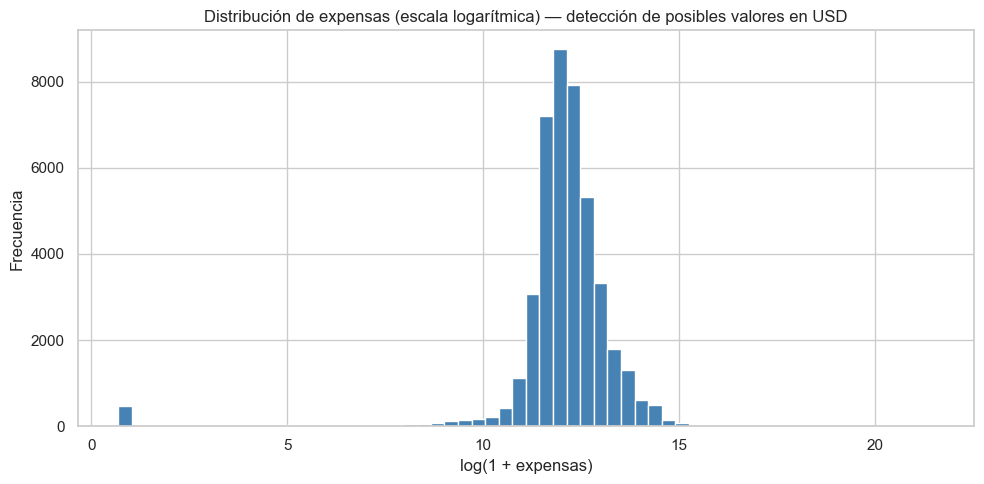

In [34]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_final['expensas'].dropna()
ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")
plt.tight_layout()
plt.show()

Vemos que hay un grupo de valores con expensas muy bajas. Para determinar dónde está el corte, usamos el gráfico de codo.

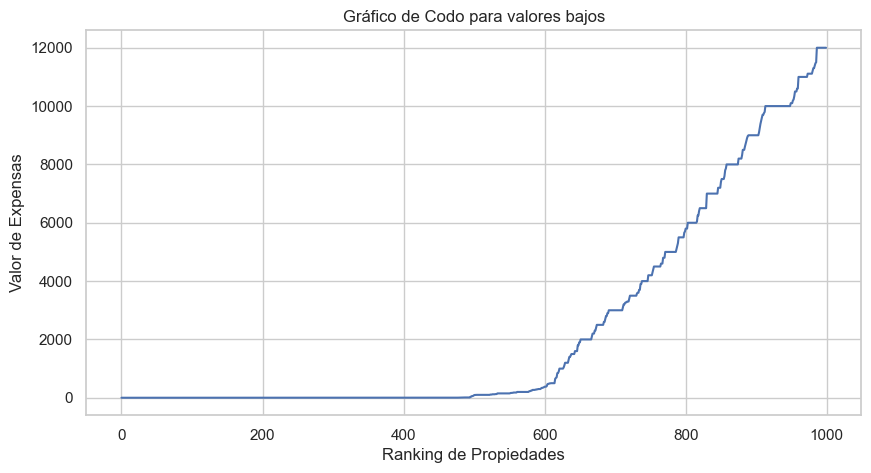

In [35]:
# Ordenamos los valores de menor a mayor
expensas_ordenadas = df_final['expensas'].dropna().sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(expensas_ordenadas[:1000]) # Miramos los primeros 500 registros más bajos
plt.ylabel("Valor de Expensas")
plt.xlabel("Ranking de Propiedades")
plt.title("Gráfico de Codo para valores bajos")
plt.show()

En este gráfico vemos que hasta la propiedad número 500 aproximadamente el valor es 0, que corresponde a departamentos sin expensas. Entre la propiedad 500 y la 600 la línea empieza a despegarse muy lentamente, con valores insignificantes (1, 10, 100 pesos), que representan casos donde la persona ingresó un número simbólico en lugar de dejar el campo vacío.

El verdadero salto de mercado, donde la pendiente se vuelve empinada y constante, empieza alrededor de la propiedad 600, que coincide con valores superiores a los $2.000 - $3.000. Ahí fijamos nuestro umbral.

In [36]:
import numpy as np

# Definimos el umbral a partir del gráfico de codo
umbral_basura = 100
umbral_minimo_mercado = 4000 

# Creamos una columna nueva para no modificar la original
df_final['expensas_ok'] = df_final['expensas']

# Aplicamos la lógica deducida del gráfico
df_final.loc[df_final['expensas'] < umbral_basura, 'expensas_ok'] = 0
mask_error = (df_final['expensas'] >= umbral_basura) & (df_final['expensas'] < umbral_minimo_mercado)
df_final.loc[mask_error, 'expensas_ok'] = np.nan

# Calculamos estadisticas sobre la columna limpia
resumen_expensas_ok = df_final.groupby('operacion')['expensas_ok'].agg(
    count='count',         
    media='mean',          # La media debería subir
    mediana='median',      # La mediana va a ser más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("Resumen de expensas LIMPIAS:")
print(resumen_expensas_ok)

# y sobre la columna original
resumen_expensas_og = df_final.groupby('operacion')['expensas'].agg(
    count='count',         
    media='mean',          # La media debería subir
    mediana='median',      # La mediana va a ser más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("\nResumen de expensas ORIGINALES:")
print(resumen_expensas_og)

# Verificamos si quedan valores sospechosos
sospechosos_nuevos = df_final[
    (df_final['expensas_ok'] > 0) & 
    (df_final['expensas_ok'] < umbral_minimo_mercado)
]['expensas_ok']

print(f"\nSospechosos en columna limpia: {len(sospechosos_nuevos)}")

# 1. Cuántos eran menores a 100 (convertidos a 0)
cant_a_cero = len(df_final[(df_final['expensas'] < 100)])

# 2. Cuántos eran "ruido" (convertidos a NaN)
cant_a_nan = len(df_final[(df_final['expensas'] >= 100) & (df_final['expensas'] < 4000)])

# 3. Resumen total
total_registros = len(df_final)

print(f"\n--- Auditoría de Limpieza de Expensas ---")
print(f"Total de registros analizados: {total_registros}")
print(f"Registros llevados a 0 (sin expensas): {cant_a_cero}")
print(f"Registros anulados (ruido/errores): {cant_a_nan}")
print(f"Total de datos modificados: {cant_a_cero + cant_a_nan}")
print(f"Porcentaje de datos 'sucios' eliminados: {((cant_a_nan / total_registros) * 100):.2f}%")

# Reemplazamos los valores de expensas por expensas_ok
df_final = df_final.drop(columns=['expensas']).rename(columns={'expensas_ok': 'expensas'})

Resumen de expensas LIMPIAS:
                   count     media   mediana       p5
operacion                                            
alquiler           17902  525461.0  180000.0  75000.0
alquiler_temporal   2972  205321.0  154124.0  15000.0
venta              21990  300591.0  190000.0  45500.0

Resumen de expensas ORIGINALES:
                   count     media   mediana       p5
operacion                                            
alquiler           17977  523271.0  180000.0  74000.0
alquiler_temporal   3009  202799.0  150000.0    540.0
venta              22113  298931.0  187200.0  40000.0

Sospechosos en columna limpia: 0

--- Auditoría de Limpieza de Expensas ---
Total de registros analizados: 62937
Registros llevados a 0 (sin expensas): 503
Registros anulados (ruido/errores): 235
Total de datos modificados: 738
Porcentaje de datos 'sucios' eliminados: 0.37%


Revisamos cómo quedó:

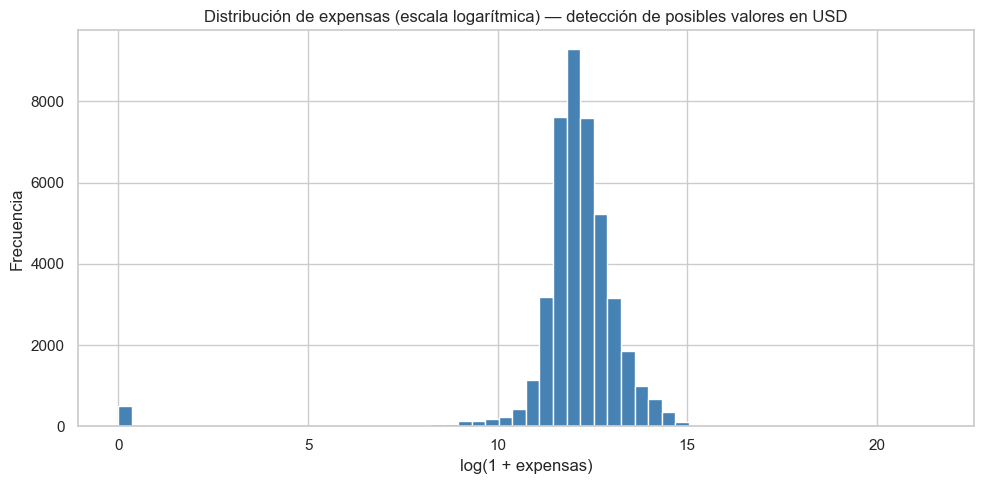

In [37]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_final['expensas'].dropna()

ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")

plt.tight_layout()
plt.show()

Ahora, el unico salto que se ve es por aquellos que determinamos que tienen expensas=0.

# 7. Valores faltantes

## Inspeccionamos

Vemos cómo se estructuran los valores faltantes.

In [38]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
       Variable  Datos_Faltantes  Porcentaje
         precio             1494    2.373802
          calle             5370    8.532342
         altura             5370    8.532342
           piso            49314   78.354545
       detalles              220    0.349556
    descripción              293    0.465545
 barrio_oficial                3    0.004767
      ambientes            30464   48.403960
antiguedad_años            36952   58.712681
          baños            21414   34.024501
    calefaccion            50844   80.785547
    cocina_tipo            42540   67.591401
    dormitorios            13624   21.647044
       m2_total             2436    3.870537
    orientacion            30324   48.181515
 tiene_expensas            33247   52.825842
       expensas            20073   31.893799


Muchos valores faltantes provienen de las columnas que agregamos en el parseo, tanto de detalles como de descripción. Separamos por sitio para ver si ZonaProp y ArgenProp presentan diferencias en la cobertura de cada campo.

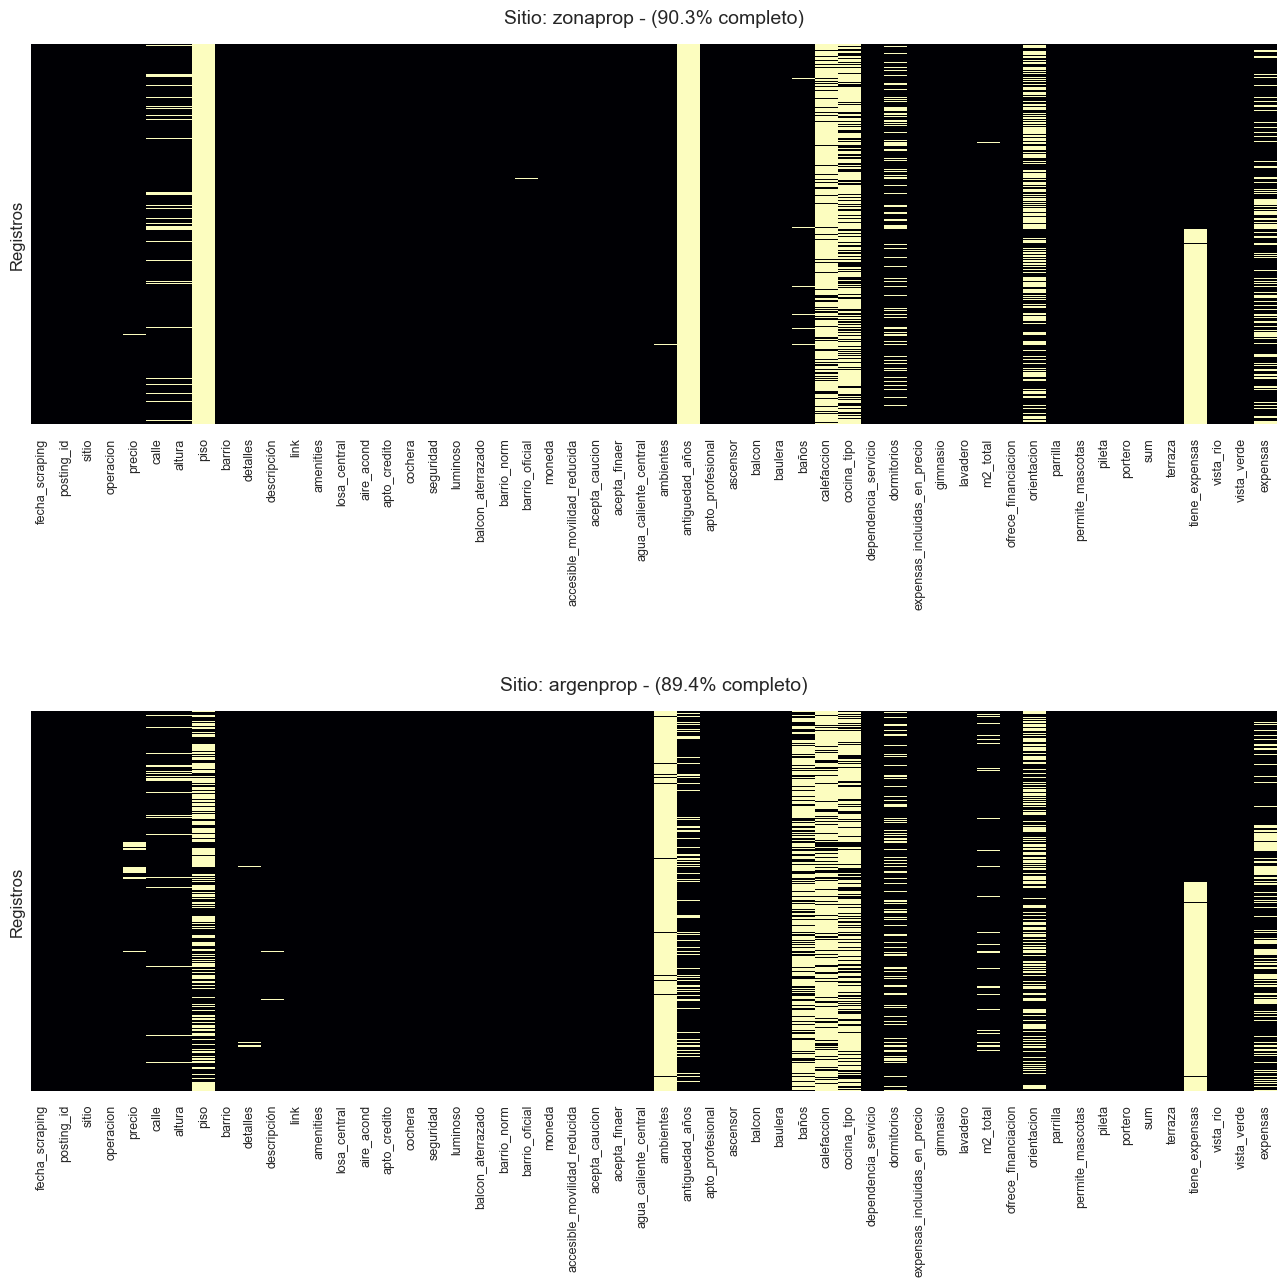

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

# Aumentamos un poco el ancho (14) para que las columnas respiren
fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    # cmap='magma' suele resaltar mejor los nulos (amarillo sobre negro/morado)
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    # Forzamos que se muestren TODAS las etiquetas
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Vemos que variables como ambientes y baños están prácticamente completas en ZonaProp y prácticamente vacías en ArgenProp, mientras que antigüedad_años ocurre al revés. A continuación revisamos cómo se compone la columna detalles en cada sitio.

In [40]:
df_final[df_final['sitio']=='zonaprop']['detalles']

0                  60 m² tot. 2 amb. 1 dorm. 1 baño
1        114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
2        121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.
3                  66 m² tot. 2 amb. 1 dorm. 1 baño
4        117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
                            ...                    
31745           150 m² tot. 2 dorm. 2 baños 1 coch.
31746              51 m² tot. 2 amb. 1 dorm. 1 baño
31747              77 m² tot. 3 amb. 2 dorm. 1 baño
31748    169 m² tot. 4 amb. 3 dorm. 2 baños 2 coch.
31749             80 m² tot. 3 amb. 2 dorm. 2 baños
Name: detalles, Length: 31750, dtype: object

In [41]:
df_final[df_final['sitio']=='argenprop']['detalles']

31750         47 m² cubie. Monoam. Bueno
31751       80 m² cubie. 2 dorm. 15 años
31752      100 m² cubie. 2 dorm. 40 años
31753        27 m² cubie. 1 baño Monoam.
31754       34 m² cubie. 1 dorm. 80 años
                      ...               
62932       63 m² cubie. 2 dorm. 30 años
62933        25 m² cubie. 40 años 1 baño
62934    60 m² cubie. 1 dorm. A Estrenar
62935       65 m² cubie. 2 dorm. 15 años
62936       62 m² cubie. 3 dorm. 50 años
Name: detalles, Length: 31187, dtype: object

Vemos reflejadas esas diferencias en la composición de la columna.

Para confirmar formalmente lo que vemos en los gráficos, realizamos un test de independencia chi-cuadrado entre el indicador de dato faltante y el sitio de origen (ArgenProp vs ZonaProp). La hipótesis nula plantea que la ausencia de un valor es independiente del sitio. Rechazarla indica que el mecanismo de faltantes depende de una variable observada (el sitio de scraping), lo que encuadra el patrón como MAR (Missing At Random condicionado al sitio) y justifica una estrategia de imputación diferenciada por sitio.

In [42]:
from scipy.stats import chi2_contingency

vars_test = ['ambientes', 'baños', 'dormitorios', 'antiguedad_años',
             'calle', 'altura', 'calefaccion', 'cocina_tipo', 'orientacion']
vars_test = [v for v in vars_test if v in df_final.columns]

resultados = []
for var in vars_test:
    indicador = df_final[var].isna().astype(int)
    if indicador.sum() == 0:
        continue
    tabla = pd.crosstab(df_final['sitio'], indicador)
    if tabla.shape[1] < 2:
        continue
    chi2_stat, p, dof, _ = chi2_contingency(tabla)
    pct = df_final.groupby('sitio')[var].apply(lambda x: x.isna().mean() * 100).round(1)
    resultados.append({
        'variable': var,
        'faltantes ArgenProp (%)': pct.get('argenprop', 0),
        'faltantes ZonaProp (%)': pct.get('zonaprop', 0),
        'chi2': round(chi2_stat, 2),
        'p-valor': round(p, 4),
        'MAR respecto a sitio': 'Sí (p < 0.05)' if p < 0.05 else 'No se rechaza H₀'
    })

df_mar = pd.DataFrame(resultados)
display(df_mar)

,variable,faltantes ArgenProp (%),faltantes ZonaProp (%),chi2,p-valor,MAR respecto a sitio
0,ambientes,96.8,0.8,58050.23,0.0000,Sí (p < 0.05)
1,baños,66.8,1.8,29558.66,0.0000,Sí (p < 0.05)
2,dormitorios,22.6,20.7,35.19,0.0000,Sí (p < 0.05)
3,antiguedad_años,16.7,100.0,45053.42,0.0000,Sí (p < 0.05)
4,calle,6.2,10.9,440.55,0.0000,Sí (p < 0.05)
5,altura,6.2,10.9,440.55,0.0000,Sí (p < 0.05)
6,calefaccion,81.4,80.2,12.67,0.0004,Sí (p < 0.05)
7,cocina_tipo,68.6,66.6,30.23,0.0000,Sí (p < 0.05)
8,orientacion,47.0,49.3,32.79,0.0000,Sí (p < 0.05)


También hay variables con muchos valores faltantes en ambos sitios, ya sea porque no estaban disponibles en el scraper (como calle, altura y piso) o porque el parseo de descripción no las capturó bien (como calefacción, cocina_tipo y orientación).

Teniendo esto en cuenta, usamos distintas técnicas para tratar los valores faltantes según el caso.

## Tratamos los valores faltantes

### Expensas

Para tratar las expensas usamos la variable tiene_expensas, que construimos a partir del parseo de descripción. Si el valor es faltante y tiene_expensas es 0, imputamos un 0. Si tiene_expensas es 1, usamos el precio y el barrio para imputar el valor.

In [43]:
# Imputación de expensas
# Todos los registros deben terminar con un valor, independientemente de quién las paga (tiene_expensas). 
# Si tiene_expensas == 0 y expensas_incluidas_en_precio == 0, las paga el propietario
# Si tiene_expensas == 0 y expensas_incluidas_en_precio == 1, las paga el inquilino indirectamente
# Si tiene expensas == 1, las paga el inquilino directamente 
# El monto existe siempre.

df_final['segmento_precio'] = pd.qcut(df_final['precio'], q=10, labels=False, duplicates='drop')

# Imputación en cascada: barrio_oficial × segmento → segmento → mediana global
df_final['expensas'] = df_final.groupby(['barrio_oficial', 'segmento_precio'])['expensas'].transform(
    lambda x: x.fillna(x.median())
)
df_final['expensas'] = df_final.groupby('segmento_precio')['expensas'].transform(
    lambda x: x.fillna(x.median())
)
df_final['expensas'] = df_final['expensas'].fillna(df_final['expensas'].median())

df_final.drop(columns=['segmento_precio'], inplace=True)

# Caso especial: avisos que publicaron precio + expensas como un solo número.
# Ahora que tenemos las expensas imputadas, las restamos del precio para limpiarlo.
# También marcamos tiene_expensas = 1 porque el inquilino sí las paga (incluidas en el alquiler).

mask_incluidas = df_final['expensas_incluidas_en_precio']
n_ajuste = mask_incluidas.sum()
df_final.loc[mask_incluidas, 'precio'] = (
    df_final.loc[mask_incluidas, 'precio'] - df_final.loc[mask_incluidas, 'expensas']
)
df_final.loc[mask_incluidas, 'tiene_expensas'] = 1
print(f"Filas con precio ajustado por 'expensas incluidas': {n_ajuste}")


# Tiene expensas aplica a las publicaciones de alquileres, no a las ventas
# Para las ventas, queda nulo porque no aplica al analisis


Filas con precio ajustado por 'expensas incluidas': 1357


### Ambientes, baños, dormitorios y antigüedad

Dado que estas variables aparecen principalmente en uno de los sitios, usamos los datos del otro como base e imputamos los valores según los m² del departamento.

In [44]:
# 1. Creamos rangos de m² para que la imputación sea coherente
df_final['m2_bin'] = pd.qcut(df_final['m2_total'], q=10, duplicates='drop')

# 2. Lista de variables estructurales a imputar
vars_estructurales = ['ambientes', 'baños', 'dormitorios', 'antiguedad_años']

for col in vars_estructurales:
    # Imputamos por la mediana de barrio y rango de m2
    df_final[col] = df_final.groupby(['barrio_oficial', 'm2_bin'])[col].transform(lambda x: x.fillna(x.median()))
    
    # Si quedan nulos (bin sin datos en ese barrio), usamos solo el bin
    df_final[col] = df_final.groupby('m2_bin')[col].transform(lambda x: x.fillna(x.median()))
    
    # Si todavia quedan nulos, usamos la mediana general
    df_final[col].fillna(df_final[col].median(), inplace=True)


# 4. Eliminamos columnas auxiliares
df_final.drop(columns='m2_bin', inplace=True, errors='ignore')

### Otras

Identificamos si la calle es una avenida, que puede ser un dato relevante.

In [45]:
avenidas_conocidas = ['avenida', 'av.', 'av ', 'diagonal']
df_final['sobre_avenida'] = df_final['calle'].str.lower().str.contains(
    '|'.join(avenidas_conocidas), na=False
).astype(int)


Finalmente, eliminamos las variables con un número muy alto de valores faltantes que no son relevantes para el análisis.

In [46]:
cols_descarte = ['piso', 'calefaccion', 'cocina_tipo', 'orientacion']
df_final.drop(columns=cols_descarte, inplace=True, errors='ignore')

## Revisamos cómo quedó

In [47]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
      Variable  Datos_Faltantes  Porcentaje
        precio             1494    2.373802
         calle             5370    8.532342
        altura             5370    8.532342
      detalles              220    0.349556
   descripción              293    0.465545
barrio_oficial                3    0.004767
      m2_total             2436    3.870537
tiene_expensas            33247   52.825842


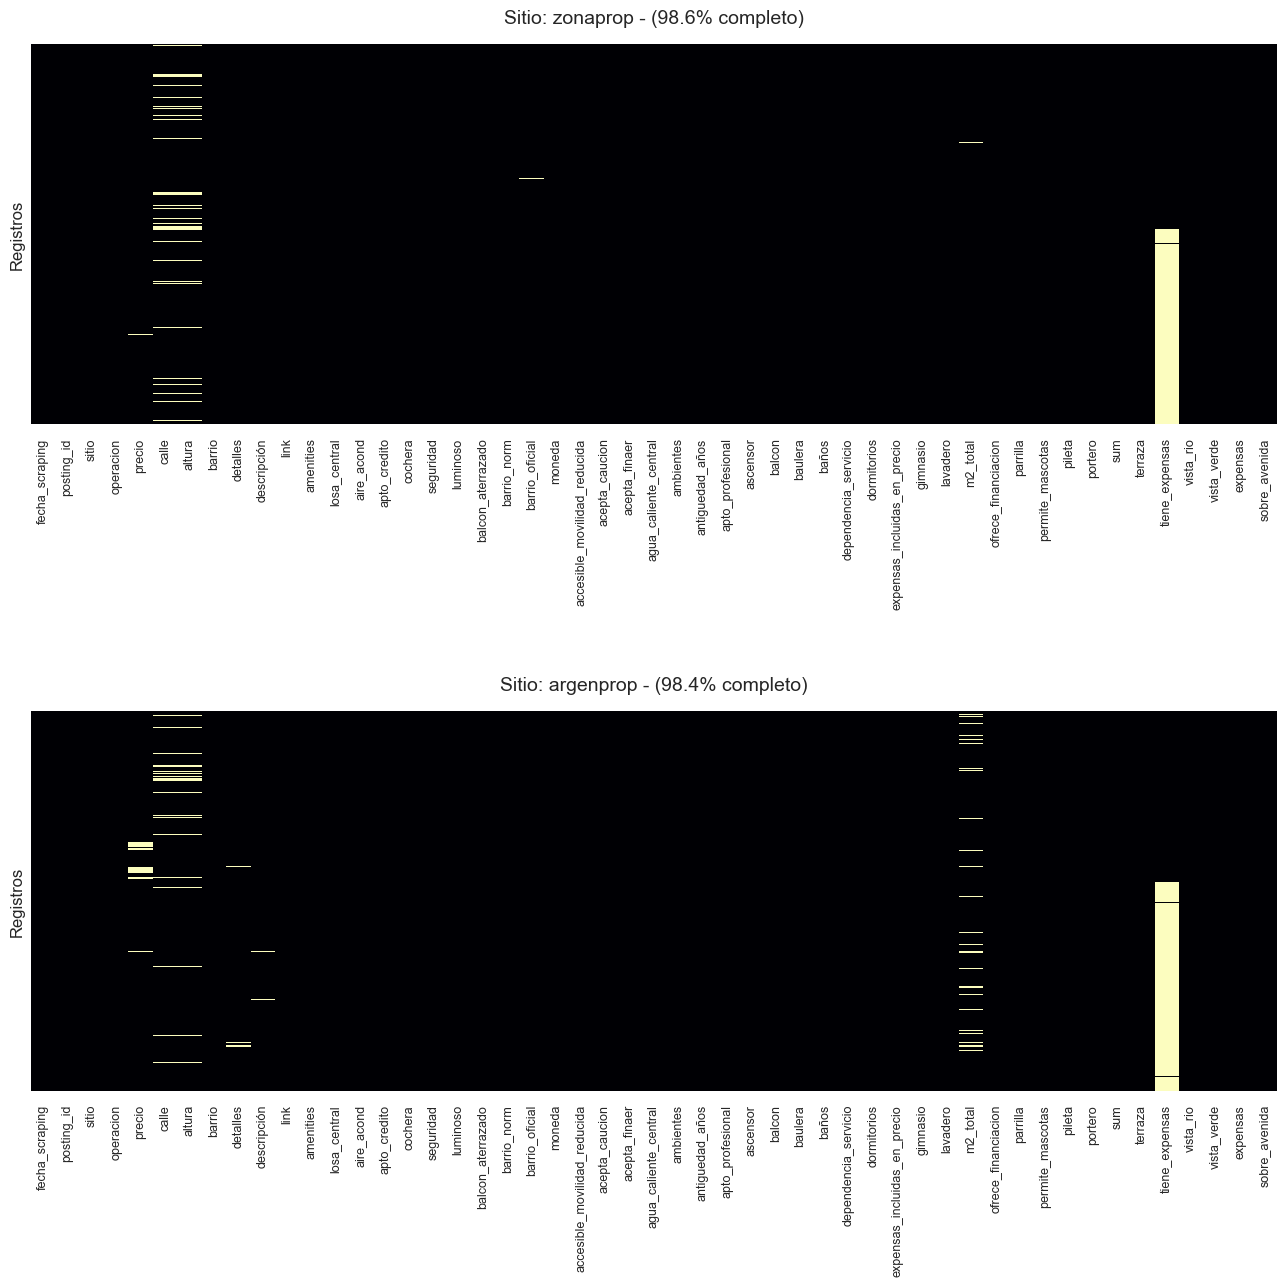

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Finalmente, eliminamos los pocos registros con datos faltantes que quedan, ya que son muy pocos y no vale la pena imputarlos. El precio y los metros cuadrados es importante que sean valores reales; y la descripción y los detalles son imposibles de completar de forma confiable.

Las columnas calle y altura las conservamos porque pueden ser útiles para un análisis geoespacial posterior, por ejemplo vinculando las propiedades con estaciones de subte. Como van a ser utilizadas exclusivamente para esos análisis, no decidimos imputar esas dos columnas. Como son ubicaciones específicas, preferimos mantener los valores que ya tenemos y no inventar ubicaciones. Además, el número de faltantes no es significativo (8.5%) para su propósito. 

La columna tiene_expensas la conservamos porque es puramente para los registros de alquileres y alquileres temporarios, no ventas

In [49]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

# 1. Eliminamos registros sin las variables fundamentales (precio y metros)
df_final.dropna(subset=['precio', 'm2_total', 'barrio_oficial'], inplace=True)

# 2. Eliminamos registros sin descripción o detalles
df_final.dropna(subset=['descripción', 'detalles'], inplace=True)

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados por nulos en variables clave: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados por nulos en variables clave: 4,114
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     14497    13658         839
                  usd      6879     6673         206
alquiler_temporal ars      2069      784        1285
                  usd      6065     5826         239
venta             ars       243       44         199
                  usd     33184    31838        1346


# 8. Tratamiento de Outliers (con precio_por_m²)

## Paso 1 - Imports

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 50)

## Paso 2 - Calcular precio_por_m²

La variable 'precio_por_m2' constituye uno de los principales indicadores comparativos del mercado inmobiliario, ya que permite homogeneizar propiedades de distintas dimensiones y tipologías.

A diferencia del precio absoluto, esta métrica facilita detectar:
- zonas sobrevaluadas o subvaluadas,
- diferencias estructurales entre barrios,
- oportunidades de inversión,
- efectos de amenities o ubicación sobre la valuación relativa.

Entonces, usamos precio_por_m2 como KPI central. Sin esta normalización, un PH de 200 m² siempre va a parecer un outlier por precio total aunque sea perfectamente normal por m².

Filtramos antes de calcular para no propagar NaN ni divisiones inválidas.

Revisamos los valores muy bajos de m² que podrían ser errores de carga, para determinar dónde está el corte.

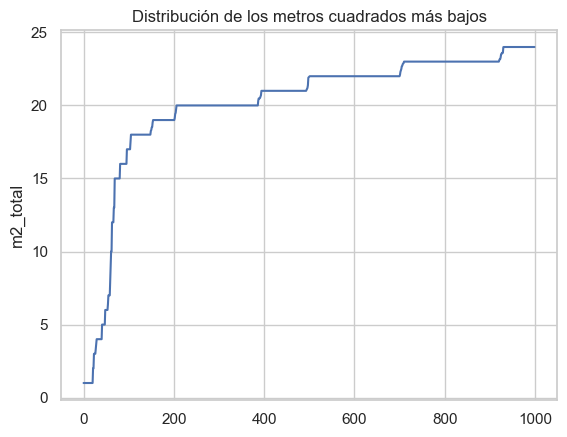

In [51]:
df_prueba = df_final.copy()

# Graficamos el "codo" de los metros cuadrados
plt.plot(df_prueba['m2_total'].sort_values().reset_index(drop=True)[:1000])
plt.title("Distribución de los metros cuadrados más bajos")
plt.ylabel("m2_total")
plt.show()

Por debajo de 15 m² hay algunos registros que no tienen sentido lógico para una unidad habitable. A partir de 15 m², la cantidad de departamentos crece claramente, lo que sugiere que los valores inferiores son errores de carga. Por eso los filtramos antes de calcular precio_por_m2.

In [52]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

mask_m2 = (
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 15) &
    df_final['precio'].notna() &
    (df_final['precio'] > 0)
)

df_final['precio_por_m2'] = float('nan')
df_final.loc[mask_m2, 'precio_por_m2'] = (
    df_final.loc[mask_m2, 'precio'] / df_final.loc[mask_m2, 'm2_total']
)

df_final = df_final[df_final['precio_por_m2'].notna()].copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados por m2 menor a 15 o precio inv??lido: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados por m2 menor a 15 o precio inv??lido: 943
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     13658    13614          44
                  usd      6673     6375         298
alquiler_temporal ars       784      781           3
                  usd      5826     5267         559
venta             ars        44       43           1
                  usd     31838    31800          38


Nos quedamos con los registros para los que se puede calcular precio_por_m2, ya que es una métrica central del análisis.

## Paso 3 - Deduplicar scraping

Al scrapear, el mismo aviso podría aparecer más de una vez. Deduplicamos usando posting_id y sitio como clave. Usar barrio, precio o m² como criterio sería incorrecto porque dos inmuebles distintos pueden coincidir en esas columnas.

In [53]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

df_final = df_final.drop_duplicates(subset=['posting_id', 'sitio'], keep='first').copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Duplicados de scraping eliminados: {log_df["eliminados"].sum():,}')
print(log_df)

assert df_final.duplicated(subset=['posting_id', 'sitio']).sum() == 0, "Todav??a hay duplicados!"

Duplicados de scraping eliminados: 4,953
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     13614    12900         714
                  usd      6375     5962         413
alquiler_temporal ars       781      677         104
                  usd      5267     4734         533
venta             ars        43       43           0
                  usd     31800    28611        3189


Revisamos qué porcentaje de registros duplicados eliminamos.

## Paso 4 - Corrección de errores de moneda

Existe una dependencia circular entre la detección de moneda y el análisis de outliers. Si un precio en USD fue clasificado como ARS por error, va a aparecer como un valor extremadamente bajo dentro del segmento ARS. Si no lo corregimos antes, puede sobrevivir los filtros de outliers cuando en realidad es un error de clasificación.

Primero graficamos la distribución de precios ARS para elegir los umbrales con criterio visual, luego reclasificamos.

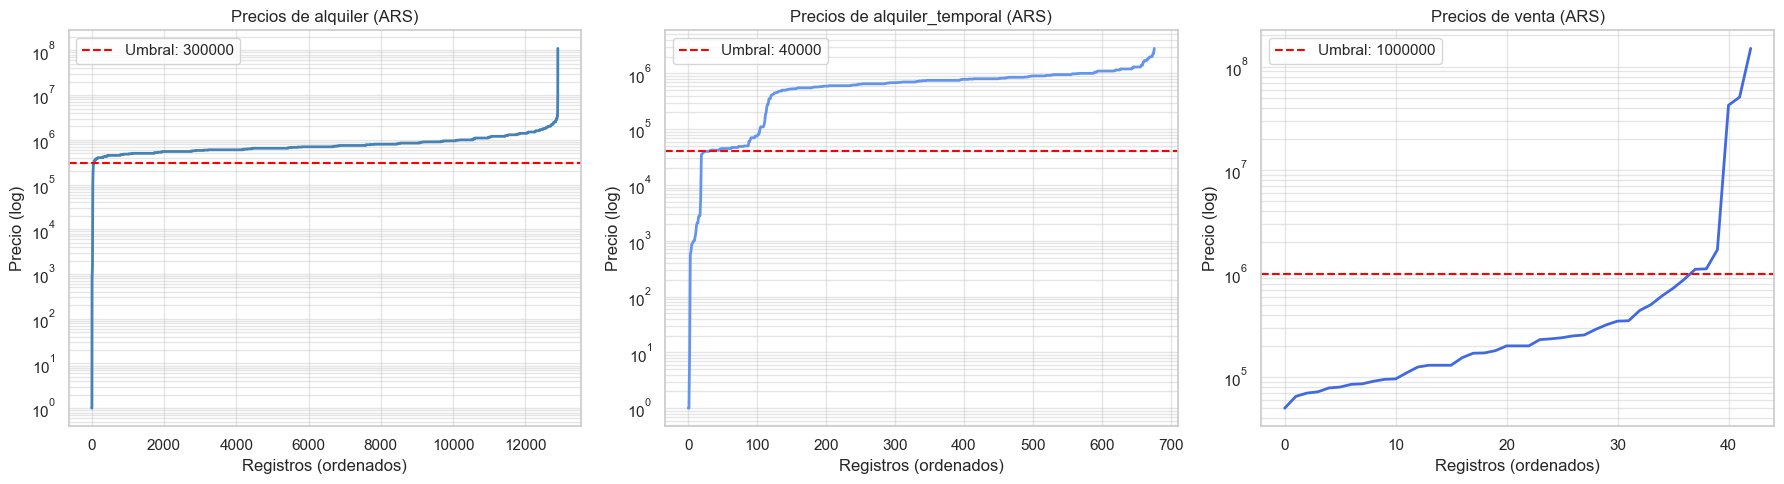

In [54]:
import matplotlib.pyplot as plt

ops = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 300000, 'alquiler_temporal': 40000, 'venta': 1000000}
colores = ['steelblue', 'cornflowerblue', 'royalblue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, op, color in zip(axes, ops, colores):
    subset = df_final[
        (df_final['moneda'] == 'ars') & (df_final['operacion'] == op)
    ]['precio'].dropna().sort_values().reset_index(drop=True)
    
    if not subset.empty:
        ax.plot(subset.values, color=color, linewidth=2)
        umb = umbrales[op]
        ax.axhline(y=umb, color='red', linestyle='--', label=f'Umbral: {umb}')
        
        ax.set_title(f'Precios de {op} (ARS)')
        ax.set_yscale('log')
        ax.set_ylabel('Precio (log)')
        ax.set_xlabel('Registros (ordenados)')
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

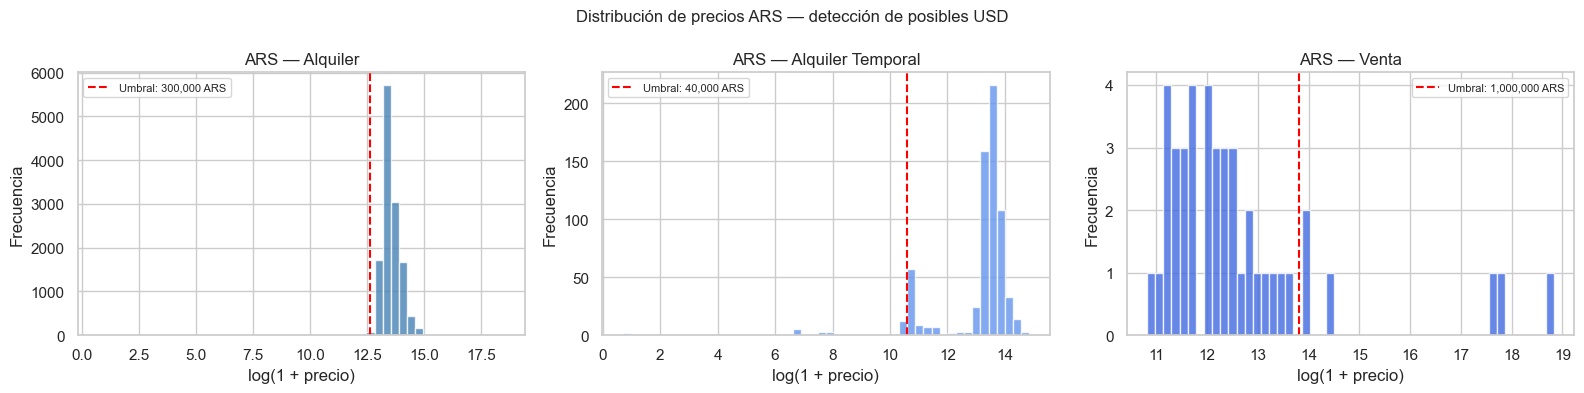

Registros ARS por debajo del umbral (candidatos a reclasificar):
  alquiler: 44 registros con precio < 300,000 ARS
  alquiler_temporal: 23 registros con precio < 40,000 ARS
  venta: 37 registros con precio < 1,000,000 ARS


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de precios ARS — detección de posibles USD', fontsize=12)

ops      = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 300_000, 'alquiler_temporal': 40_000, 'venta': 1_000_000}
#umbrales = {'alquiler': 120_000, 'alquiler_temporal': 100_000, 'venta': 100_000}
colores  = ['steelblue', 'cornflowerblue', 'royalblue']

for ax, op, color in zip(axes, ops, colores):
    subset = df_final[
        (df_final['moneda'] == 'ars') & (df_final['operacion'] == op)
    ]['precio'].dropna()

    ax.hist(np.log1p(subset), bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(
        np.log1p(umbrales[op]),
        color='red', linestyle='--',
        label=f'Umbral: {umbrales[op]:,} ARS'
    )
    ax.set_title(f"ARS — {op.replace('_', ' ').title()}")
    ax.set_xlabel('log(1 + precio)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Registros ARS por debajo del umbral (candidatos a reclasificar):")
for op, umbral in umbrales.items():
    n = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    ).sum()
    print(f"  {op}: {n} registros con precio < {umbral:,} ARS")

Un alquiler ARS menor a 300.000 pesos en 2026 es imposible para el mercado de CABA; probablemente esté expresado en dólares.

Un alquiler temporal ARS menor a 40.000 pesos en 2026 también está fuera del rango de mercado; probablemente esté en dólares.

Una venta ARS menor a 1.000.000 pesos en 2026 está igualmente fuera del rango de mercado; probablemente esté en dólares.

Por eso reclasificamos estos registros.

In [56]:
UMBRALES_IMPOSIBLES_ARS = {
    'alquiler':           300_000,
    'alquiler_temporal':  40_000,
    'venta':             1_000_000,
}

n_reclasificados = 0
for op, umbral in UMBRALES_IMPOSIBLES_ARS.items():
    mask = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    )
    n_reclasificados += mask.sum()
    df_final.loc[mask, 'moneda'] = 'usd'
    print(f"  Reclasificados '{op}': {mask.sum()} registros")

print(f"\nTotal reclasificados ARS → USD: {n_reclasificados}")

  Reclasificados 'alquiler': 44 registros
  Reclasificados 'alquiler_temporal': 23 registros
  Reclasificados 'venta': 37 registros

Total reclasificados ARS → USD: 104


Probamos algo similar para registros en dólares con valores demasiado altos, que probablemente están expresados en pesos.

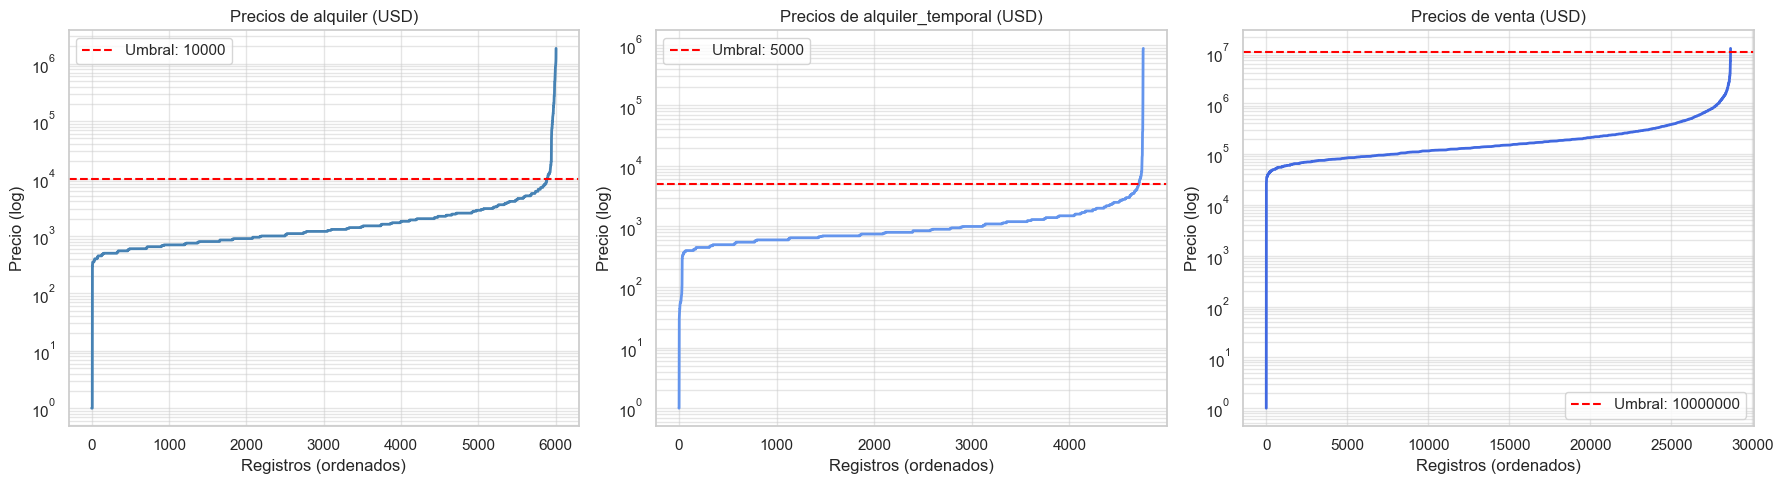

Registros USD por arriba del umbral (candidatos a reclasificar):
  alquiler: 108 registros con precio > 10,000 USD
  alquiler_temporal: 44 registros con precio > 5,000 USD
  venta: 1 registros con precio > 10,000,000 USD


In [57]:
import matplotlib.pyplot as plt

ops = ['alquiler', 'alquiler_temporal', 'venta']
# Definimos los umbrales en un diccionario
umbrales = {'alquiler': 10000, 'alquiler_temporal': 5000, 'venta': 10000000}
colores = ['steelblue', 'cornflowerblue', 'royalblue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, op, color in zip(axes, ops, colores):
    # .sort_values() para ver el codo
    subset = df_final[
        (df_final['moneda'] == 'usd') & (df_final['operacion'] == op)
    ]['precio'].dropna().sort_values().reset_index(drop=True)
    
    if not subset.empty:
        ax.plot(subset.values, color=color, linewidth=2)
        umb = umbrales[op]
        ax.axhline(y=umb, color='red', linestyle='--', label=f'Umbral: {umb}')
        
        ax.set_title(f'Precios de {op} (USD)')
        ax.set_yscale('log')
        ax.set_ylabel('Precio (log)')
        ax.set_xlabel('Registros (ordenados)')
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

print("Registros USD por arriba del umbral (candidatos a reclasificar):")
for op, umbral in umbrales.items():
    n = (
        (df_final['moneda'] == 'usd') &
        (df_final['operacion'] == op) &
        (df_final['precio'] > umbral)
    ).sum()
    print(f"  {op}: {n} registros con precio > {umbral:,} USD")

Definimos estos niveles como umbral de corte.

In [58]:
UMBRALES_IMPOSIBLES_USD = {
    'alquiler':           10_000,
    'alquiler_temporal':  5_000,
    'venta':             10_000_000,
}

n_reclasificados = 0
for op, umbral in UMBRALES_IMPOSIBLES_USD.items():
    mask = (
        (df_final['moneda'] == 'usd') &
        (df_final['operacion'] == op) &
        (df_final['precio'] > umbral)
    )
    n_reclasificados += mask.sum()
    df_final.loc[mask, 'moneda'] = 'ars'
    print(f"  Reclasificados '{op}': {mask.sum()} registros")

print(f"\nTotal reclasificados USD → ARS: {n_reclasificados}")

  Reclasificados 'alquiler': 108 registros
  Reclasificados 'alquiler_temporal': 44 registros
  Reclasificados 'venta': 1 registros

Total reclasificados USD → ARS: 153


## Paso 5 - Filtros absolutos

Eliminamos valores que son imposibles en cualquier contexto del mercado. Estos errores contaminarían el cálculo de percentiles si los dejamos adentro, por eso se aplican antes del paso de Winsorización.

En el paso anterior corregíamos la moneda asignada; en este paso eliminamos directamente los registros que no tienen sentido en ningún segmento.

In [59]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

PISO_USD_ALQUILER = 5        # USD/m2  imposible en cualquier barrio de CABA
PISO_USD_VENTA    = 400      # USD/m2  por debajo casi seguro error de moneda
PISO_ARS_ALQUILER = 3_000    # ARS/m2  mínimo razonable post-corrección
TECHO_USD_M2      = 25_000   # USD/m2  por encima error de tipeo

mask_error = (
    ((df_final['operacion'] == 'venta') &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_VENTA))
    |
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_ALQUILER))
    |
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'ars') &
     (df_final['precio_por_m2'] < PISO_ARS_ALQUILER))
    |
    (df_final['precio_por_m2'] > TECHO_USD_M2)
)

df_final = df_final[~mask_error].copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados por filtros absolutos de precio/m2: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados por filtros absolutos de precio/m2: 931
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     12964    12339         625
                  usd      5898     5881          17
alquiler_temporal ars       698      459         239
                  usd      4713     4674          39
venta             ars         7        4           3
                  usd     28647    28639           8


## Paso 6 - Percentiles adaptativos y Winsorización

Para los valores extremos que sí existen en el mercado (propiedades de lujo, PHs grandes), winsorizamos en lugar de eliminar. Reemplazamos el valor extremo por el límite del percentil, conservando el registro con todas sus variables para el modelo.

El percentil es adaptativo por segmento. Calculamos P1-P99 por operacion + moneda + barrio. Si el barrio tiene menos de 30 registros, usamos operacion + moneda como fallback para que el percentil sea estadísticamente válido.

Esto es importante porque Villa Lugano y Puerto Madero tienen rangos de precios completamente distintos. Un percentil global trataría como outlier propiedades perfectamente normales en cada uno.

In [60]:
N_MIN         = 30     # mínimo de registros para usar percentil por barrio
SEG_FINO      = ['operacion', 'moneda', 'barrio_oficial']
SEG_GRUESO    = ['operacion', 'moneda']
Q_LOW, Q_HIGH = 0.01, 0.99


def calcular_percentiles_adaptativos(df, col, seg_fino, seg_grueso, q_low, q_high, n_min):
    """Calcula percentiles por segmento fino; usa segmento grueso si n < n_min."""
    df = df.copy()

    stats_fino = (
        df.groupby(seg_fino)[col]
        .agg(
            n      = 'count',
            p_low  = lambda x: x.quantile(q_low),
            p_high = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )
    stats_grueso = (
        df.groupby(seg_grueso)[col]
        .agg(
            p_low_fb  = lambda x: x.quantile(q_low),
            p_high_fb = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )

    df = df.merge(stats_fino,   on=seg_fino,   how='left')
    df = df.merge(stats_grueso, on=seg_grueso, how='left')

    df['p_low']  = np.where(df['n'] >= n_min, df['p_low'],  df['p_low_fb'])
    df['p_high'] = np.where(df['n'] >= n_min, df['p_high'], df['p_high_fb'])

    return df.drop(columns=['n', 'p_low_fb', 'p_high_fb'])


df_final = calcular_percentiles_adaptativos(
    df_final, 'precio_por_m2',
    SEG_FINO, SEG_GRUESO,
    Q_LOW, Q_HIGH, N_MIN
)

# Guardamos el valor original para referencia y para el paso siguiente
df_final['precio_por_m2_original'] = df_final['precio_por_m2'].copy()

# Winsorizamos: reemplazamos por el límite en lugar de eliminar
mask_sup = df_final['precio_por_m2'] > df_final['p_high']
mask_inf = df_final['precio_por_m2'] < df_final['p_low']

df_final.loc[mask_sup, 'precio_por_m2'] = df_final.loc[mask_sup, 'p_high']
df_final.loc[mask_inf, 'precio_por_m2'] = df_final.loc[mask_inf, 'p_low']

print(f"Winsorizados por encima del P{Q_HIGH*100:.0f}: {mask_sup.sum():,}")
print(f"Winsorizados por debajo del P{Q_LOW*100:.0f}:  {mask_inf.sum():,}")
print(f"Total winsorizados: {(mask_sup | mask_inf).sum():,} ({(mask_sup | mask_inf).mean()*100:.1f}%)")

df_final = df_final.drop(columns=['p_low', 'p_high'])

Winsorizados por encima del P99: 507
Winsorizados por debajo del P1:  574
Total winsorizados: 1,081 (2.1%)


Dado que son pocos registros, podemos imputarles los valores del límite del percentil sin modificar notablemente la distribución de las variables.

## Paso 7 - Alquiler temporal ARS: precios por noche

El alquiler temporal en ARS mezcla precios por noche con precios por mes. Un departamento de 35 m² a 600 ARS corresponde a un precio por noche, equivalente a aproximadamente 18.000 ARS/m² mensual, que es perfectamente razonable.

Estos registros se eliminan directamente porque la razón es una unidad de tiempo incompatible con el resto del segmento. Sin saber si el precio es por noche, por semana o por mes, no hay forma de convertirlos de manera confiable.

In [61]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

UMBRAL_NOCHE_ARS = 2_000   # ARS/m2 implícito; por debajo precio por noche

mask_at_ars    = (
    (df_final['operacion'] == 'alquiler_temporal') &
    (df_final['moneda'] == 'ars')
)
mask_por_noche = mask_at_ars & (df_final['precio_por_m2_original'] < UMBRAL_NOCHE_ARS)

df_final = df_final[~mask_por_noche].copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados alquiler temporal ARS por noche: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados alquiler temporal ARS por noche: 0
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     12339    12339           0
                  usd      5881     5881           0
alquiler_temporal ars       459      459           0
                  usd      4674     4674           0
venta             ars         4        4           0
                  usd     28639    28639           0


## Paso 8 - Features de zona

Segmentamos los barrios en tres categorías que el modelo puede usar como variable. Puerto Madero funciona como un mercado aparte (con precios 2 a 3 veces la media), y los barrios populares tienen un piso de precios sistemáticamente más bajo.

En lugar de eliminar estos registros, los marcamos para tener en cuenta el efecto de zona de forma explícita.

In [62]:
BARRIOS_PREMIUM   = ['Puerto Madero']
BARRIOS_POPULARES = [
    'Villa Lugano', 'Villa Riachuelo', 'Villa Soldati',
    'Mataderos', 'Liniers', 'Parque Patricios'
]

df_final['segmento_zona'] = np.where(
    df_final['barrio_oficial'].isin(BARRIOS_PREMIUM),    'premium',
    np.where(
        df_final['barrio_oficial'].isin(BARRIOS_POPULARES), 'popular',
        'estandar'
    )
)

print("Distribución por segmento de zona:")
print(df_final['segmento_zona'].value_counts())

print("\nMediana precio/m² por zona (venta USD):")
print(
    df_final[df_final['operacion'] == 'venta']
    .groupby('segmento_zona')['precio_por_m2']
    .agg(['count', 'median', 'min', 'max'])
    .round(0)
)

Distribución por segmento de zona:
segmento_zona
estandar    48932
premium      1765
popular      1299
Name: count, dtype: int64

Mediana precio/m² por zona (venta USD):
               count  median   min    max
segmento_zona                            
estandar       27106   2,551   560  8,511
popular          962   1,851   645  3,731
premium          575   5,667 3,366 16,471


## Paso 9 - Consolidar segmentos con poco volumen

Algunos combos operacion + moneda + segmento_zona quedaron con muy pocos registros (por ejemplo, alquiler USD popular con n=4). 

Llevamos los segmentos pequeños a estandar para tratarlos junto con el grupo mayoritario.

In [63]:
N_MIN_SEG = 30

conteo = df_final.groupby(
    ['operacion', 'moneda', 'segmento_zona']
)['precio_por_m2'].transform('count')

df_final['segmento_zona_modelo'] = np.where(
    conteo < N_MIN_SEG,
    'estandar',
    df_final['segmento_zona']
)

print("Distribución final segmento_zona_modelo:")
print(
    df_final.groupby(['operacion', 'moneda', 'segmento_zona_modelo'])
    .size()
    .to_frame('n')
)

Distribución final segmento_zona_modelo:
                                                   n
operacion         moneda segmento_zona_modelo       
alquiler          ars    estandar              12013
                         popular                 326
                  usd    estandar               4949
                         premium                 932
alquiler_temporal ars    estandar                459
                  usd    estandar               4425
                         premium                 249
venta             ars    estandar                  4
                  usd    estandar              27103
                         popular                 962
                         premium                 574


## Paso 10 - Transformación logarítmica

Los precios inmobiliarios tienen distribución log-normal. La diferencia relativa entre 50.000 y 100.000 USD es equivalente a la diferencia entre 200.000 y 400.000 USD. El logaritmo captura esta relación y estabiliza la varianza.

Usamos log1p(x) = log(1 + x) en lugar de log(x) porque es numéricamente estable para valores cercanos a 0 y es invertible con expm1() para recuperar la escala original.

In [64]:
df_final['log_precio']    = np.log1p(df_final['precio'])
df_final['log_m2']        = np.log1p(df_final['m2_total'])
df_final['log_precio_m2'] = np.log1p(df_final['precio_por_m2'])

print("Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2")

Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2


## Paso 11 - Reporte y validación final

Verificamos que no hayan quedado NaN ni infinitos en las variables clave, y revisamos que los rangos por segmento sean coherentes con el mercado.

Sobre el gráfico: los puntos fuera de los bigotes del boxplot son normales. Seaborn marca como outlier cualquier punto más allá de 1.5×IQR, que es un criterio más estricto que nuestro P1-P99. Son los extremos reales del mercado dentro del rango que definimos como válido.

DATASET FINAL: 51,996 registros
OK — sin NaN ni infinitos en variables clave

Distribución por segmento:
                              n     p5  mediana    p95
operacion         moneda                              
alquiler          ars     12339 11,333   16,731 23,118
                  usd      5881     11       19     35
alquiler_temporal ars       459 11,458   18,750 24,643
                  usd      4674     10       18     33
venta             ars         4  3,632    4,271  5,708
                  usd     28639  1,378    2,551  4,979


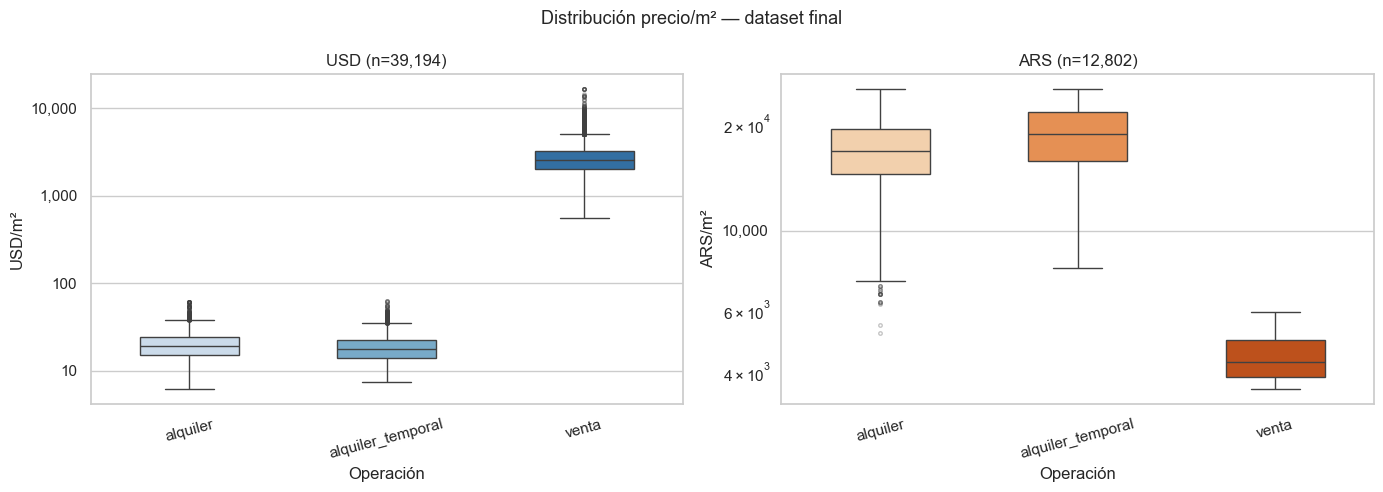

In [65]:
print("=" * 55)
print(f"DATASET FINAL: {len(df_final):,} registros")
print("=" * 55)

# Verificamos que no queden NaN ni infinitos en variables clave
vars_clave = ['precio', 'm2_total', 'precio_por_m2',
              'log_precio', 'log_m2', 'log_precio_m2']
nans = df_final[vars_clave].isna().sum()
infs = (df_final[vars_clave] == np.inf).sum()
assert nans.sum() == 0, f"Hay NaN:\n{nans[nans > 0]}"
assert infs.sum() == 0, f"Hay infinitos:\n{infs[infs > 0]}"
print("OK — sin NaN ni infinitos en variables clave")

# Distribución por segmento
print("\nDistribución por segmento:")
resumen = (
    df_final
    .groupby(['operacion', 'moneda'])['precio_por_m2']
    .agg(
        n       = 'count',
        p5      = lambda x: x.quantile(0.05),
        mediana = 'median',
        p95     = lambda x: x.quantile(0.95)
    )
    .round(0)
)
print(resumen)

# Graficamos con escala logarítmica en el eje Y para legibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución precio/m² — dataset final', fontsize=13)

for ax, (moneda, palette) in zip(axes, [('usd', 'Blues'), ('ars', 'Oranges')]):
    datos = df_final[df_final['moneda'] == moneda]
    sns.boxplot(
        x='operacion', y='precio_por_m2',
        data=datos, ax=ax,
        palette=palette, width=0.5,
        flierprops=dict(marker='.', markersize=5, alpha=0.3)
    )
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_title(f'{moneda.upper()} (n={len(datos):,})')
    ax.set_xlabel('Operación')
    ax.set_ylabel(f'{moneda.upper()}/m²')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

El valor bajo de los departamentos en venta en ARS sospechamos que se debe a la poca cantidad de registros (40) y al tipo de inmueble que se oferta en pesos, que suelen ser propiedades deterioradas en remate.

## Interpretación de outliers

Finalmente, podemos decir que la presencia de valores extremos resulta esperable dentro del mercado inmobiliario, especialmente en segmentos de lujo o propiedades corporativas.

Sin embargo, también se detectaron inconsistencias atribuibles a errores de carga, diferencias monetarias o publicaciones incompletas. Por ello, se aplicaron técnicas de filtrado y winsorización buscando preservar propiedades genuinamente exclusivas sin distorsionar las métricas generales del mercado.

Este enfoque permite mantener representatividad estadística sin eliminar segmentos relevantes del negocio inmobiliario.

# 9. Selección de Variables

In [66]:
df_final.columns

Index(['fecha_scraping', 'posting_id', 'sitio', 'operacion', 'precio', 'calle',
       'altura', 'barrio', 'detalles', 'descripción', 'link', 'amenities',
       'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
       'luminoso', 'balcon_aterrazado', 'barrio_norm', 'barrio_oficial',
       'moneda', 'accesible_movilidad_reducida', 'acepta_caucion',
       'acepta_finaer', 'agua_caliente_central', 'ambientes',
       'antiguedad_años', 'apto_profesional', 'ascensor', 'balcon', 'baulera',
       'baños', 'dependencia_servicio', 'dormitorios',
       'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'm2_total',
       'ofrece_financiacion', 'parrilla', 'permite_mascotas', 'pileta',
       'portero', 'sum', 'terraza', 'tiene_expensas', 'vista_rio',
       'vista_verde', 'expensas', 'sobre_avenida', 'precio_por_m2',
       'precio_por_m2_original', 'segmento_zona', 'segmento_zona_modelo',
       'log_precio', 'log_m2', 'log_precio_m2'],
      dtype='object')

Empezamos eliminando las variables que claramente no son útiles para el análisis futuro. La fecha del scraping y el link no los utilizaremos, sacamos toda la info necesaria de 'detalles' y 'descripcion' y el conteo de amenities ya no es exacto al haber agregado más columnas. 

In [67]:
df_final = df_final.drop(columns=[
    'fecha_scraping', 'detalles', 'descripción', 'link', 'amenities'
])

df_final = df_final.drop(columns=['precio_por_m2_original'])
# barrio_oficial es la versión final normalizada
df_final = df_final.drop(columns=['barrio', 'barrio_norm'])

print(f"Columnas restantes ({len(df_final.columns)}):")
print(df_final.columns.tolist())

Columnas restantes (50):
['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura', 'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda', 'accesible_movilidad_reducida', 'acepta_caucion', 'acepta_finaer', 'agua_caliente_central', 'ambientes', 'antiguedad_años', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños', 'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla', 'permite_mascotas', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'vista_rio', 'vista_verde', 'expensas', 'sobre_avenida', 'precio_por_m2', 'segmento_zona', 'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2']


Mantenemos el sitio y el ID de la publicación ya que pueden ser útiles posteriormente al momento de crear un tablero en Power BI. 

Analizamos las variables binarias y eliminamos aquellas que están presentes en menos del 2% o más del 95% de los registros.

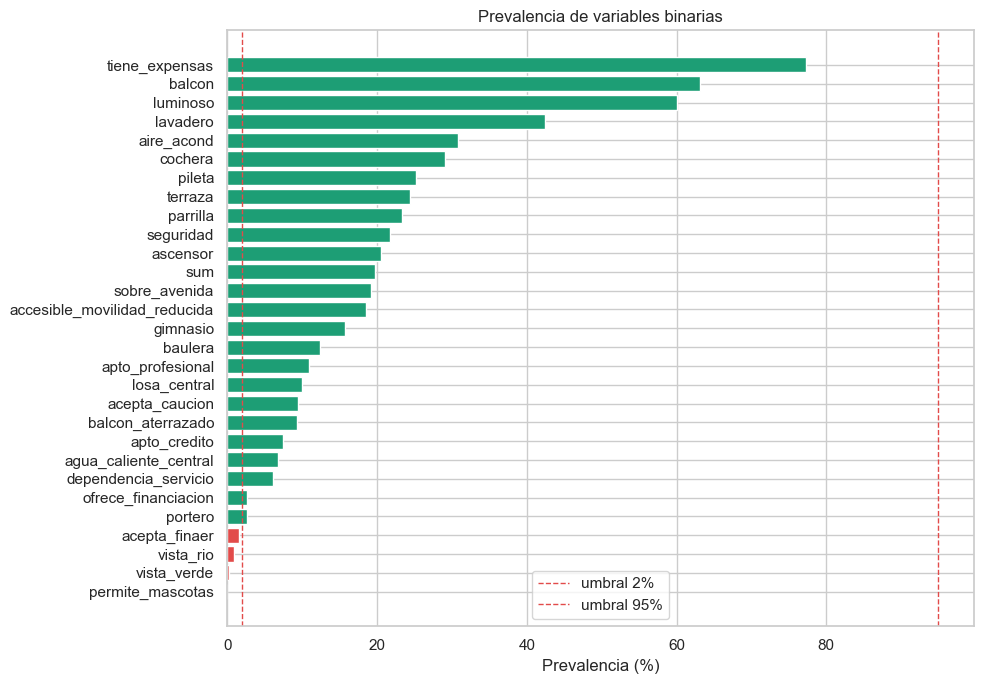


Variables a eliminar por baja variación: ['permite_mascotas', 'vista_verde', 'vista_rio', 'acepta_finaer']


In [68]:
cols_binarias = [
    'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
    'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida',
    'acepta_caucion', 'acepta_finaer', 'agua_caliente_central', 'apto_profesional',
    'ascensor', 'balcon', 'baulera', 'dependencia_servicio', 'gimnasio',
    'lavadero', 'ofrece_financiacion', 'parrilla', 'permite_mascotas',
    'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas',
    'vista_rio', 'vista_verde', 'sobre_avenida'
]
cols_binarias = [c for c in cols_binarias if c in df_final.columns]

prevalencia = df_final[cols_binarias].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#E24B4A' if v < 0.02 or v > 0.95 else '#1D9E75' for v in prevalencia]
ax.barh(prevalencia.index, prevalencia.values * 100, color=colores)
ax.axvline(2,  color='#E24B4A', linestyle='--', linewidth=1, label='umbral 2%')
ax.axvline(95, color='#E24B4A', linestyle='--', linewidth=1, label='umbral 95%')
ax.set_xlabel('Prevalencia (%)')
ax.set_title('Prevalencia de variables binarias')
ax.legend()
plt.tight_layout()
plt.show()

# Variables a eliminar por baja variación
eliminar_prevalencia = prevalencia[(prevalencia < 0.02) | (prevalencia > 0.95)].index.tolist()
print(f"\nVariables a eliminar por baja variación: {eliminar_prevalencia}")
df_final = df_final.drop(columns=eliminar_prevalencia)
cols_binarias = [c for c in cols_binarias if c not in eliminar_prevalencia]

Creamos una variable que cuenta la cantidad de amenities por propiedad.

In [69]:
df_final['amenities_count'] = df_final[cols_binarias].sum(axis=1)

print("Distribución de amenities_count:")
print(df_final['amenities_count'].describe())

Distribución de amenities_count:
count   51,996
mean         5
std          3
min          0
25%          3
50%          5
75%          7
max         18
Name: amenities_count, dtype: float64


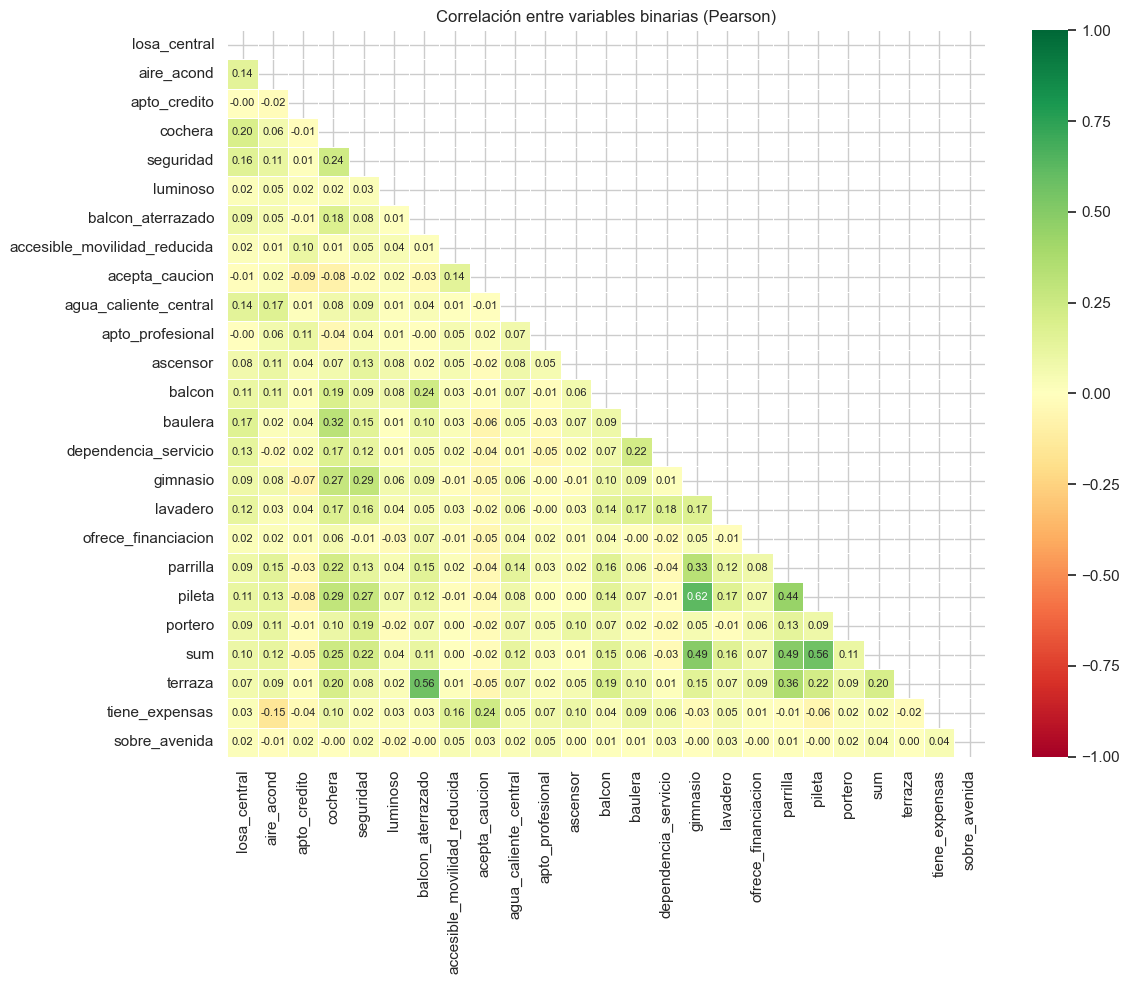


Pares con |r| > 0.85:
Empty DataFrame
Columns: [var_1, var_2, correlacion, correlacion_abs]
Index: []


In [70]:
corr_bin = df_final[cols_binarias].corr(method='pearson')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_bin, dtype=bool))
sns.heatmap(
    corr_bin, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlación entre variables binarias (Pearson)')
plt.tight_layout()
plt.show()

# Tabla de pares con |r| > 0.85
upper = corr_bin.where(np.triu(np.ones(corr_bin.shape), k=1).astype(bool))
pares = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var_1', 'level_1': 'var_2', 0: 'correlacion'})
    .assign(correlacion_abs=lambda x: x['correlacion'].abs())
    .sort_values('correlacion_abs', ascending=False)
)
print("\nPares con |r| > 0.85:")
print(pares[pares['correlacion_abs'] > 0.85].to_string(index=False))

No encontramos ninguna correlación fuerte entre las distintas variables binarias. La correlación más fuerte (0.62) está presente entre pileta y gimnasio. Tiene sentido que si un edificio presenta espacio para pileta, también cuente con un gimnasio (y vice-versa), pero la asociación no es tan fuerte para que sea representativo en la mayoría de los casos.

# Descarga del dataframe limpio

In [71]:
import os

OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

filename = "dataframe_limpio.tsv"
filepath = os.path.join(OUTPUT_DIR, filename)
df_final.to_csv(filepath, sep='\t', index=False, encoding='utf-8-sig')
print(f"\n✅ ¡Éxito! Guardado en: {filepath}")


✅ ¡Éxito! Guardado en: ../data/processed/dataframe_limpio.tsv
